### LSTM

LSTM is a type of recurrent neural network capable of learning the dependence in a sequence of predictions. With it's capability of using its memory cells to store relevant information and gates that address the continuous read, write and reset of the memory cells, it can handle linear and nonlinear time series. 

The LSTM was one of the models used to predict the number of bee colonies in the US. With the use of its architecture, the LSTM was able to account for the trends and seasonality for each of the time series in the datasets. Using the rolling window to perform cross validation, the datasets were structured in matrix format for the LSTM. The number of lags used as the rolling window was 3 years. With the use of epochs as part of to create and fit the model, the LSTM determines the minimum mean squared and saves the best model with a call back function, ModelCheckPoint. With its call back function of early stopping, when the minimum squared loss wasn't improving after 2 epochs, the model stops fitting and saves the best model.

As part of the project, two attempts of modeling were done to predict the outcome. The first model used one hot encoding to represent each of the states as part of the features in the data set. As a result, the number of features increased. 
Unfortantely, the predictions were not accurate.

The second attempt used each state as a separate time series to obtain it's best lstm model. The results for the validation and test data were more accurate compared to the one hot encoding.

In [1]:
import statsmodels.api as sm
import matplotlib as mplt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re
import math
import numpy as np
import pandas as pd
import datetime as dt
import tensorflow as tf
from os.path import abspath, exists
from os import makedirs
from keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import MinMaxScaler
from IPython.display import Image, display
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger

%matplotlib inline

### Preprocess of data sets

In [2]:
# function to read file into a dataframe
def read_file(filename):
    # read the data file
    fileName = "data/" + filename
    fPath = abspath(fileName)
    print(f"fpath = {fPath}")
    assert exists(fPath), f"{fileName} doesn't exist"
    df = pd.read_csv(fPath)
    return df

In [3]:
# read the files
dataset_a_df = read_file('dataset_a.csv')
dataset_b_df = read_file('dataset_b.csv')

# convert the year to datetime
dataset_a_df['year'] = pd.to_datetime(dataset_a_df['year'], format="%Y-%m-%d")
dataset_b_df['year'] = pd.to_datetime(dataset_b_df['year'], format="%Y-%m-%d")

fpath = c:\Georgia Tech\LinkToDrive\OneDrive - Georgia Institute of Technology\CDA6740\Project\OfficialProject\data\dataset_a.csv
fpath = c:\Georgia Tech\LinkToDrive\OneDrive - Georgia Institute of Technology\CDA6740\Project\OfficialProject\data\dataset_b.csv


In [4]:
display(dataset_a_df.head())
dataset_a_df.drop(columns=['Unnamed: 0'], inplace=True)
print(f"dataset index = {dataset_a_df.columns}")

,Unnamed: 0,year,state,colonies_inventory,days_with_aqi,good_days,moderate_days,unhealthy_for_sensitive_groups_days,unhealthy_days,very_unhealthy_days,...,90th_percentile_aqi,median_aqi,days_co,days_no2,days_ozone,days_pm2.5,days_pm10,temperature_max,temperature_min,precipitation_total
0,0,1987-01-01,alabama,46000,230.571429,130.714286,66.428571,24.428571,7.857143,1.142857,...,107.571429,46.285714,13.428571,0.000000,181.142857,0.0,36.000000,92.6,32.5,48.13
1,1,1987-01-01,arizona,80000,162.100000,88.700000,60.500000,11.900000,1.000000,0.000000,...,76.400000,42.600000,40.800000,6.100000,79.200000,0.0,36.000000,93.1,27.1,13.28
2,2,1987-01-01,arkansas,29000,184.000000,136.333333,35.333333,8.666667,3.666667,0.000000,...,64.000000,31.666667,0.000000,16.666667,101.666667,0.0,65.666667,93.5,28.9,53.10
3,3,1987-01-01,california,540000,302.163265,168.612245,74.918367,29.591837,17.551020,11.469388,...,110.979592,53.102041,30.571429,63.469388,190.734694,0.0,17.387755,89.5,31.4,19.70
4,4,1987-01-01,colorado,44000,222.000000,134.388889,74.888889,10.500000,1.777778,0.444444,...,70.333333,38.333333,46.388889,25.055556,107.666667,0.0,42.888889,82.6,12.4,18.82


dataset index = Index(['year', 'state', 'colonies_inventory', 'days_with_aqi', 'good_days',
       'moderate_days', 'unhealthy_for_sensitive_groups_days',
       'unhealthy_days', 'very_unhealthy_days', 'hazardous_days', 'max_aqi',
       '90th_percentile_aqi', 'median_aqi', 'days_co', 'days_no2',
       'days_ozone', 'days_pm2.5', 'days_pm10', 'temperature_max',
       'temperature_min', 'precipitation_total'],
      dtype='object')


In [5]:
display(dataset_b_df.head())
dataset_b_df.drop(columns=['Unnamed: 0'], inplace=True)

,Unnamed: 0,year,state,colonies_inventory,colonies_renovated_pct,colonies_loss_deadout_pct,colonies_disease_pct,colonies_varroa_mites_pct,colonies_other_causes_pct,colonies_pesticides_pct,...,90th_percentile_aqi,median_aqi,days_co,days_no2,days_ozone,days_pm2.5,days_pm10,temperature_max,temperature_min,precipitation_total
0,0,2015-01-01,alabama,7000,4.25,15.50,0.050,23.225,4.325,1.825,...,56.222222,39.333333,0.000000,0.666667,137.666667,145.722222,3.222222,91.9,30.0,61.36
1,1,2015-01-01,arizona,26000,26.75,19.00,1.775,34.725,9.525,10.225,...,66.230769,40.461538,0.000000,3.384615,207.615385,45.153846,103.076923,94.2,28.1,14.39
2,2,2015-01-01,arkansas,24000,10.75,16.00,2.375,47.700,9.675,9.800,...,54.454545,35.090909,0.000000,2.636364,157.727273,87.909091,0.000000,91.6,26.1,67.31
3,3,2015-01-01,california,275000,13.00,11.75,7.375,38.200,11.550,15.450,...,84.537037,49.425926,0.074074,5.592593,213.555556,111.018519,13.962963,91.0,32.8,15.04
4,4,2015-01-01,colorado,29000,5.00,11.25,7.575,37.825,4.525,9.900,...,54.774194,35.451613,0.096774,9.354839,202.193548,19.612903,58.709677,81.8,14.2,21.73


In [6]:
# sort by the dates to ensure the rolling window
dataset_a_df.sort_values(by=['year', 'state'], inplace=True)
dataset_b_df.sort_values(by=['year', 'state'], inplace=True)

In [7]:
# save a copy of the dataset_a_df and dataset_b_df in case need to get original back
cp_dataset_a_df = dataset_a_df.copy()
cp_dataset_b_df = dataset_b_df.copy()

In [8]:
# check the data from stats models
from statsmodels.tsa.stattools import adfuller

In [9]:
states = dataset_a_df['state'].unique().tolist()
print(states)

['alabama', 'arizona', 'arkansas', 'california', 'colorado', 'florida', 'georgia', 'hawaii', 'idaho', 'illinois', 'indiana', 'iowa', 'kansas', 'kentucky', 'louisiana', 'maine', 'michigan', 'minnesota', 'mississippi', 'missouri', 'montana', 'nebraska', 'new jersey', 'new york', 'north carolina', 'north dakota', 'ohio', 'oregon', 'pennsylvania', 'south dakota', 'tennessee', 'texas', 'utah', 'vermont', 'virginia', 'washington', 'west virginia', 'wisconsin', 'wyoming']


In [10]:
print(f"tail of dataset_a = {cp_dataset_a_df.tail()}")
print(f"head of dataset_a = {cp_dataset_a_df.head()}")

print(f"tail of dataset_b = {cp_dataset_b_df.tail()}")
print(f"head of dataset_b = {cp_dataset_b_df.head()}")

tail of dataset_a =            year          state  colonies_inventory  days_with_aqi  good_days  \
1399 2022-01-01       virginia                8250       60.96875  57.468750   
1400 2022-01-01     washington               83500       30.20000  23.366667   
1401 2022-01-01  west virginia                5250       41.75000  40.000000   
1402 2022-01-01      wisconsin               45500       31.43750  27.250000   
1403 2022-01-01        wyoming                7000       83.50000  81.700000   

      moderate_days  unhealthy_for_sensitive_groups_days  unhealthy_days  \
1399       3.500000                             0.000000        0.000000   
1400       6.633333                             0.166667        0.033333   
1401       1.750000                             0.000000        0.000000   
1402       4.187500                             0.000000        0.000000   
1403       1.700000                             0.100000        0.000000   

      very_unhealthy_days  hazardous_days 

#### Create a mapping of the column names from one hot encoding to state using the label encoder

In [11]:
# call the label encoder to obtain the correspoding columns
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
# save the state_list to translate back
states_list = cp_dataset_a_df.state.unique().tolist()
print(f"states_list = {states_list}")
label_encoding = label_encoder.fit_transform(cp_dataset_a_df.state.unique())

states_list = ['alabama', 'arizona', 'arkansas', 'california', 'colorado', 'florida', 'georgia', 'hawaii', 'idaho', 'illinois', 'indiana', 'iowa', 'kansas', 'kentucky', 'louisiana', 'maine', 'michigan', 'minnesota', 'mississippi', 'missouri', 'montana', 'nebraska', 'new jersey', 'new york', 'north carolina', 'north dakota', 'ohio', 'oregon', 'pennsylvania', 'south dakota', 'tennessee', 'texas', 'utah', 'vermont', 'virginia', 'washington', 'west virginia', 'wisconsin', 'wyoming']


In [12]:
state_to_label = dict(zip(states_list, label_encoding))
label_to_state = dict(zip(label_encoding, states_list))

### One Hot Encoding

Each state is represented by a label column and the bit set to 1 when the data belons to the corresponding state.

In [13]:
# convert to one hot encoding
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore')

encoder_a_df = pd.DataFrame(encoder.fit_transform(cp_dataset_a_df[['state']]).toarray())
encoder_b_df = pd.DataFrame(encoder.fit_transform(cp_dataset_b_df[['state']]).toarray())
cp_dataset_a_df = cp_dataset_a_df.join(encoder_a_df)
cp_dataset_b_df = cp_dataset_b_df.join(encoder_b_df)

In [14]:
# remove the state column as well since already did one hot encoder and obtain the training, validation and testing data
cp_dataset_a_df.drop(columns=['state'], inplace=True)
cp_dataset_b_df.drop(columns=['state'], inplace=True)

In [15]:
print(f"cp_dataset_b tail {cp_dataset_b_df.tail()}")

cp_dataset_b tail           year  colonies_inventory  colonies_renovated_pct  \
307 2022-01-01                8250                     4.0   
308 2022-01-01               83500                    13.5   
309 2022-01-01                5250                    19.5   
310 2022-01-01               45500                     1.0   
311 2022-01-01                7000                     4.0   

     colonies_loss_deadout_pct  colonies_disease_pct  \
307                       11.5                  1.70   
308                        6.5                  3.95   
309                       10.5                  2.65   
310                        4.0                  2.45   
311                        5.0                  2.55   

     colonies_varroa_mites_pct  colonies_other_causes_pct  \
307                      28.25                      15.05   
308                      29.55                       8.40   
309                      14.45                       3.50   
310                      17.

### Split of train, validation, and test data sets for one hot encoding

In [16]:
# now split the data to training, validation and test
# less than 2017 is training, 2017-2021 validation, greater than 2021 is testing
training_a_mask = (cp_dataset_a_df['year'].dt.year < 2017)
training_b_mask = (cp_dataset_b_df['year'].dt.year < 2017)

validation_a_mask = ((cp_dataset_a_df['year'].dt.year >= 2014) & \
                                 (pd.to_datetime(cp_dataset_a_df['year']).dt.year <= 2021))

validation_b_mask = ((cp_dataset_b_df['year'].dt.year >= 2017) & \
                                 (pd.to_datetime(cp_dataset_b_df['year']).dt.year <= 2021))

testing_a_mask = (cp_dataset_a_df['year'].dt.year > 2021)
testing_b_mask = (cp_dataset_b_df['year'].dt.year > 2021)

                                              
train_a_df = cp_dataset_a_df[training_a_mask].copy()
train_a_dates = train_a_df['year'].dt.year.unique()
train_b_df = cp_dataset_b_df[training_b_mask].copy()
train_b_dates = train_b_df['year'].dt.year.unique()

validation_a_df = cp_dataset_a_df[validation_a_mask].copy()
validation_a_dates = validation_a_df['year'].dt.year.unique()
validation_b_df = cp_dataset_b_df[validation_b_mask].copy()
validation_b_dates = validation_b_df['year'].dt.year.unique()

test_a_df = cp_dataset_a_df[testing_a_mask].copy()
test_a_dates = test_a_df['year'].dt.year.unique()
test_b_df = cp_dataset_b_df[testing_b_mask].copy()
test_b_dates = test_b_df['year'].dt.year.unique()

### create_matrix() for one hot encoding

The LSTM needs to have the data in matrix format and ensure that the data is scaled as well. Returns a structure containing the scaler, the original data, the original matrix, scaled matrix for the data sets.

In [17]:
# create a dictionary to hold each of the data sets for each of the states since the dictionary will hold the LSTM
# embeddings as well.
def create_matrix(a_df_list, b_df_list, states_list):
    # train, test, validation
    feature_a_list = a_df_list[0].columns.difference(['year', 'state', 'colonies_inventory', 
                                                      'days_with_aqi', 'good_days', 'moderate_days', 
                                                      'unhealthy_for_sensitive_groups_days',
                                                    'max_aqi', '90th_percentile', 'median_aqi',
                                                     'median_days', 'days_co', 'days_pm10', 'temperature_max', 
                                                      'temperature_min',
                                                     'precipitation_total'])
    feature_b_list = b_df_list[0].columns.difference(['year', 'state', 'colonies_inventory'])
    
    target_list = ['colonies_inventory']

    num_states = len(states_list)
    
    data_info_a_dict = {}
    data_info_b_dict = {}

    # data type
    data_list = ['train', 'valid', 'test']
    
    # process a first
    for i, (a, d) in enumerate(zip(data_list, a_df_list)):
        
        # create an entry for each dataframe
        data_info_a_dict[a] = {}
        data_info_a_dict[a]['df'] = d.copy()
        
        df = d.copy()
        
        # set the year as an index
        df.set_index(['year'], inplace=True)
        
        data_info_a_dict[a]['xMatrix'] = df[feature_a_list].to_numpy()
        data_info_a_dict[a]['yMatrix'] = df[target_list].to_numpy()
        
        #print(f"data_info_a_dict {a} xMatrix shape {data_info_a_dict[a]['xMatrix'].shape}")
        #print(f"data_info_a_dict {a} yMatrix shape {data_info_a_dict[a]['yMatrix'].shape}")
    
        data_info_a_dict[a]['xScaler'] = MinMaxScaler()
        data_info_a_dict[a]['yScaler'] = MinMaxScaler()
    
        data_info_a_dict[a]['xScaled'] = data_info_a_dict[a]['xScaler'].fit_transform(data_info_a_dict[a]['xMatrix'][:,:-num_states])
        data_info_a_dict[a]['yScaled'] = data_info_a_dict[a]['yScaler'].fit_transform(data_info_a_dict[a]['yMatrix'])
        
        # attach the binary values
        data_info_a_dict[a]['xScaled'] = np.hstack((data_info_a_dict[a]['xScaled'],
                                                    data_info_a_dict[a]['xMatrix'][:,-num_states:]))
    # process b
    for i, (b, d) in enumerate(zip(data_list, b_df_list)):
        
        # create an entry for each dataframe
        data_info_b_dict[b] = {}
        data_info_b_dict[b]['df'] = d.copy()
        
        df = d.copy()
        
        # set the year as an index
        df.set_index(['year'], inplace=True)
        print(f"df {b} shape {df.shape}")
        
        data_info_b_dict[b]['xMatrix'] = df[feature_b_list].to_numpy()
        data_info_b_dict[b]['yMatrix'] = df[target_list].to_numpy()
    
        data_info_b_dict[b]['xScaler'] = MinMaxScaler()
        data_info_b_dict[b]['yScaler'] = MinMaxScaler()
    
        # scale only the numerical values
        data_info_b_dict[b]['xScaled'] = data_info_b_dict[b]['xScaler'].fit_transform(data_info_b_dict[b]['xMatrix'][:,:-num_states])
        data_info_b_dict[b]['yScaled'] = data_info_b_dict[b]['yScaler'].fit_transform(data_info_b_dict[b]['yMatrix'])
        
        # attach the binary values
        data_info_b_dict[b]['xScaled'] = np.hstack((data_info_b_dict[b]['xScaled'],
                                                    data_info_b_dict[b]['xMatrix'][:,-num_states:]))
        
        
    return data_info_a_dict, data_info_b_dict

In [18]:
a_df_list = [train_a_df, validation_a_df, test_a_df]
b_df_list = [train_b_df, validation_b_df, test_b_df]

data_a_info_dict, data_b_info_dict = create_matrix(a_df_list, b_df_list, states_list)

df train shape (78, 69)
df valid shape (195, 69)
df test shape (39, 69)


In [19]:
print(f"train a = {train_a_df.tail()}")
print(f"train b = {train_b_df.tail()}")
print(f"valid a = {validation_a_df.tail()}")
print(f"valid b= {validation_b_df.tail()}")
print(f"test a = {test_a_df.tail()}")
print(f"test b= {test_b_df.tail()}")

train a =            year  colonies_inventory  days_with_aqi   good_days  moderate_days  \
1165 2016-01-01                5000     254.852941  227.794118      25.970588   
1166 2016-01-01               84000     348.758621  317.448276      30.344828   
1167 2016-01-01                5000     272.571429  237.785714      34.071429   
1168 2016-01-01               54000     282.925926  243.259259      35.851852   
1169 2016-01-01               40000     329.388889  286.222222      42.944444   

      unhealthy_for_sensitive_groups_days  unhealthy_days  \
1165                             1.088235        0.000000   
1166                             0.793103        0.172414   
1167                             0.714286        0.000000   
1168                             3.555556        0.259259   
1169                             0.166667        0.055556   

      very_unhealthy_days  hazardous_days     max_aqi  ...   29   30   31  \
1165                  0.0             0.0   91.264706  ... 

In [20]:
data_a_dict, data_b_dict = create_matrix(a_df_list, b_df_list, states_list)

#print(f"data_a_dict {data_a_dict}")
#print(f"data_b_dict {data_b_dict}")

df train shape (78, 69)
df valid shape (195, 69)
df test shape (39, 69)


### lstm_data_matrix_transform() for one hot encoding

Function that does the rolling window for the datasets with one hot encoding since the offsets into the time series will be offset by the number of states.

In [21]:

def lstm_data_matrix_transform(x_scaled_data, y_scaled_data, y_orig_data, y_dates, n_past=3, n_future=1, num_states=38):
    x, y, y_orig, d = list(), list(), list(), list()

    for i in range(n_past*num_states, x_scaled_data.shape[0] - n_future*num_states+1, num_states):
        x.append(x_scaled_data[i-n_past*num_states:i, 0:x_scaled_data.shape[1]])
        first_offset_y = i+n_future*num_states - 1*num_states
        second_offset_y = i+n_future*num_states
        y.append(y_scaled_data[first_offset_y:second_offset_y])
        y_orig.append(y_orig_data[first_offset_y:second_offset_y])
        d_offset = int(i/num_states)
        d.append(y_dates[d_offset+n_future - 1:d_offset+n_future])

    x_array, y_array, y_orig_array = (np.array(x), np.array(y), np.array(y_orig))
    
    return x_array, y_array, y_orig_array, d

In [22]:
from sklearn.metrics import mean_squared_error as mse

def plot_predictions(model, X, y, y_orig, d, y_scaler, file_name, num_states):
    
    predictions = model.predict(X).flatten()[:, np.newaxis]
    # need to turn back the original
    predict_y_data = y_scaler.inverse_transform(predictions)
   
    # years
    year_list = []
    for i in range(len(d)):
        if d[i].size > 0:
            for j in range(num_states):
                year_list.append(dt.datetime.strptime(str(d[i][0]), "%Y"))
    
    # attempt new 
    actual_y_data = y_orig.flatten()[:, np.newaxis]
    
    df = pd.DataFrame(data={"year" : year_list, "predictions":predict_y_data[:,0], "actuals": actual_y_data[:,0]})
    
    file_out_dir = "output_csv/" + file_name
    file_out = abspath(file_out_dir)
    df.to_csv(file_out)
    
    return df

In [23]:
#model = Sequential()
#model.add(LSTM(100, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)))
#model.add(LSTM(100, activation='relu'))
#model.add(Dense(n_features))
#model.compile(optimizer='adam', loss='mse')
# fit model
#model.fit(X, y, epochs=400, verbose=0)
## demonstrate prediction
#x_input = array([[70,75,145], [80,85,165], [90,95,185]])
#x_input = x_input.reshape((1, n_steps, n_features))
#yhat = model.predict(x_input, verbose=0)
#print(yhat)

### Convert the one hot encoding data matrices to the LSTM 3D format along with rolling window

In [24]:
# now need to reshape the time frames but considering the various states with windowing

x_a_train, y_a_train, y_o_a_train, d_a_train = lstm_data_matrix_transform(data_a_dict['train']['xScaled'], 
                            data_a_dict['train']['yScaled'], data_a_dict['train']['yMatrix'],
                                train_a_dates, num_states=len(states_list))

#x_a_test, y_a_test, d_a_test = lstm_data_matrix_transform(data_a_dict['test']['xScaled'], 
#                            data_a_dict['test']['yScaled'], 
#                                test_a_dates, num_states=len(states_list))

x_a_valid, y_a_valid, y_o_a_valid, d_a_valid = lstm_data_matrix_transform(data_a_dict['valid']['xScaled'], 
                            data_a_dict['valid']['yScaled'], data_a_dict['valid']['yMatrix'],
                                validation_a_dates, num_states=len(states_list))

x_b_train, y_b_train, y_o_b_train, d_b_train = lstm_data_matrix_transform(data_b_dict['train']['xScaled'], 
                            data_b_dict['train']['yScaled'], data_b_dict['train']['yMatrix'],
                                train_b_dates, num_states=len(states_list))

#x_b_test, y_b_test, d_b_test = lstm_data_matrix_transform(data_b_dict['valid']['xScaled'], 
#                            data_b_dict['valid']['yScaled'], 
#                                test_b_dates, num_states=len(states_list))

x_b_valid, y_b_valid, y_o_b_valid, d_b_valid = lstm_data_matrix_transform(data_b_dict['valid']['xScaled'], 
                            data_b_dict['valid']['yScaled'], data_b_dict['valid']['yMatrix'],
                                validation_b_dates, num_states=len(states_list))

print(f"shape original train a x {data_a_dict['train']['xScaled'].shape} y {data_a_dict['train']['yScaled'].shape} d {len(train_a_dates)}")
print(f"shape original train b x {data_b_dict['train']['xScaled'].shape} y {data_b_dict['train']['yScaled'].shape} d {len(train_b_dates)}")
#print(f"shape original test b x {data_a_dict['test']['xScaled'].shape} y {data_a_dict['test']['yScaled'].shape} d {len(test_a_dates)}")
#print(f"shape original test b x {data_b_dict['test']['xScaled'].shape} y {data_b_dict['test']['yScaled'].shape} d {len(test_b_dates)}")
print(f"shape original valid a x {data_a_dict['valid']['xScaled'].shape} y {data_a_dict['valid']['yScaled'].shape} d {len(validation_a_dates)}")
print(f"shape original valid b x {data_b_dict['valid']['xScaled'].shape} y {data_b_dict['valid']['yScaled'].shape} d {len(validation_b_dates)}")

print(f"x_train a shape {x_a_train.shape} y_train shape = {y_a_train.shape} d_train shape = {len(d_a_train)}")
print(f"x_train b shape {x_b_train.shape} y_train shape = {y_b_train.shape} d_train shape = {len(d_b_train)}")
#print(f"x_test a shape {x_a_test.shape} y_train shape = {y_a_test.shape} d_train shape = {len(d_a_test)}")
#print(f"x_test b shape {x_b_test.shape} y_train shape = {y_b_test.shape} d_train shape = {len(d_b_test)}")
print(f"x_valid a shape {x_a_valid.shape} y_valid shape = {y_a_valid.shape} d_valid shape = {len(d_a_valid)}")
print(f"x_valid b shape {x_b_valid.shape} y_valid shape = {y_b_valid.shape} d_valid shape = {len(d_b_valid)}")

shape original train a x (1170, 46) y (1170, 1) d 30
shape original train b x (78, 68) y (78, 1) d 2
shape original valid a x (312, 46) y (312, 1) d 8
shape original valid b x (195, 68) y (195, 1) d 5
x_train a shape (27, 117, 46) y_train shape = (27, 39, 1) d_train shape = 27
x_train b shape (0,) y_train shape = (0,) d_train shape = 0
x_valid a shape (5, 117, 46) y_valid shape = (5, 39, 1) d_valid shape = 5
x_valid b shape (2, 117, 68) y_valid shape = (2, 39, 1) d_valid shape = 2


In [25]:
from tensorflow.keras.layers import TimeDistributed, RepeatVector

### LSTM model for one hot encoding dataset a

In [26]:
# left here
# implement LSTM
lstm_model = Sequential()
lstm_model.add(LSTM(x_a_train.shape[2], activation='relu', input_shape=(x_a_train.shape[1], x_a_train.shape[2]), 
        return_sequences=True))
RepeatVector(len(states_list))

lstm_model.add(LSTM(x_a_train.shape[2], return_sequences=True))
#lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(.3))
lstm_model.add(LSTM(50, return_sequences=False))
#lstm_model.add(Dense(len(states_list), activation='relu'))
lstm_model.add(Dropout(.2))
#lstm_model.add(Dense(len(states_list), activation='relu'))

lstm_model.add(Dense(len(states_list), activation='relu'))

early_stopping = EarlyStopping(monitor="val_loss", patience=2, mode="min")

file_best_name = "saved_models/weights-improvement.hdf5"
file_best_path = abspath(file_best_name) 
model_chkpt = ModelCheckpoint(file_best_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

file_log_name = "my_logs.csv"
file_log_path = abspath(file_log_name)
log_csv = CSVLogger(file_log_path, separator=',', append=False)

callback_list = [early_stopping, model_chkpt, log_csv]

lstm_model.compile(loss='mse', optimizer='adam', metrics=['mse', 'mae', 'mape'])
    
lstm_model.summary()

history = lstm_model.fit(x_a_train, y_a_train, epochs=10, validation_data=(x_a_valid,y_a_valid), 
                shuffle=False, callbacks=callback_list)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 117, 46)           17112     
                                                                 
 lstm_1 (LSTM)               (None, 117, 46)           17112     
                                                                 
 dropout (Dropout)           (None, 117, 46)           0         
                                                                 
 lstm_2 (LSTM)               (None, 50)                19400     
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
                                                                 
 dense (Dense)               (None, 39)                1989      
                                                                 
Total params: 55,613
Trainable params: 55,613
Non-traina

In [27]:
# load the model
from tensorflow.keras.models import load_model

#file_best_name = "saved_models/"
model = load_model(file_best_path)
y_scaler = data_a_dict['train']['yScaler']

train_one_df = plot_predictions(model, x_a_train, y_a_train, y_o_a_train, d_a_train, 
                            y_scaler, "predict_a.csv", len(states_list))

1/1 [==============================] - 2s 2s/step


In [28]:
# obtain the original values of the mapping for which state the predicted values belong too
a_df = data_a_dict['train']['df']
num_states = len(states_list)

# remove the 1987 year since LSTM offset by one when rolling window.
a_df = a_df[a_df['year'].dt.year >= 1988]
labels_a_df = a_df.iloc[:, -num_states:].copy()


labels_a_df['state'] = labels_a_df.idxmax(1)

labels_a_df['state'] = labels_a_df['state'].map(label_to_state)
labels_a_df.reset_index(inplace=True, drop=True)

#print(f"labels_a_df head {labels_a_df.head()}")
#print(f"train_one_df shape {train_one_df.shape} labels_a_df shape {labels_a_df.shape}")

h_train_df = train_one_df.join(labels_a_df['state'])
print(f"head of h_train_df {h_train_df.head()}")

head of h_train_df         year    predictions  actuals       state
0 1990-01-01    3000.000000    29000     alabama
1 1990-01-01    3000.000000    67000     arizona
2 1990-01-01   31685.400391    42000    arkansas
3 1990-01-01  366523.468750   480000  california
4 1990-01-01   19070.978516    55000    colorado


In [29]:
print(f"dates = {train_a_dates} len = {len(train_a_dates)}")

dates = [1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000
 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014
 2015 2016] len = 30


In [30]:
#x_scaler = data_info_a_dict['train']['xScaler']
y_scaler = data_a_dict['valid']['yScaler']

valid_one_df = plot_predictions(model, x_a_valid, y_a_valid, y_o_a_valid, d_a_valid, y_scaler, "valid_a.csv", len(states_list))

1/1 [==============================] - 0s 70ms/step


In [31]:
# obtain the original values of the mapping for which state the predicted values belong too
v_df = data_a_dict['valid']['df']
num_states = len(states_list)

# remove the 1987 year since LSTM offset by one when rolling window.
#print(f"train dates = {d_a_train}")
v_df = v_df[v_df['year'].dt.year >= 2017]
labels_v_df = v_df.iloc[:, -num_states:].copy()


labels_v_df['state'] = labels_v_df.idxmax(1)

labels_v_df['state'] = labels_v_df['state'].map(label_to_state)
labels_v_df.reset_index(inplace=True, drop=True)

#print(f"labels_a_df head {labels_v_df.head()}")
#print(f"valid_one_df shape {valid_one_df.shape} labels_a_df shape {labels_v_df.shape}")

h_valid_df = valid_one_df.join(labels_v_df['state'])
print(f"head of h_valid_df {h_valid_df.head()}")
print(f"tail of h_valid_df {h_valid_df.tail()}")



head of h_valid_df         year    predictions  actuals       state
0 2017-01-01    4000.000000     7000     alabama
1 2017-01-01   81897.296875    22000     arizona
2 2017-01-01   51547.816406    29000    arkansas
3 2017-01-01  325147.062500   335000  california
4 2017-01-01    4000.000000    33000    colorado
tail of h_valid_df           year   predictions  actuals          state
190 2021-01-01   4000.000000     6000       virginia
191 2021-01-01  46479.773438    96000     washington
192 2021-01-01   4000.000000     6000  west virginia
193 2021-01-01   4000.000000    42000      wisconsin
194 2021-01-01   4000.000000    38000        wyoming


### Beginning of LSTM per State

#### lstm_state_matrix_transform() 

Transforms the data matrices into a 3D matrix using rolling window for the LSTM to perform cross validation to train the model.

In [32]:
# using the rolling window to train the LSTM will need to restructure the data into a form that the LSTM
# will generate the correct format
def lstm_state_matrix_transform(x_scaled_data, y_scaled_data, y_orig_data, y_dates, n_past=3, n_future=1):
    # Changes data to the format for LSTM training 
    # for sliding window approach
    # Prepare the list for the transformed data
    x, y, y_orig, d = list(), list(), list(), list()
    
    for i in range(n_past, x_scaled_data.shape[0] - n_future+1):
        x.append(x_scaled_data[i-n_past:i, 0:x_scaled_data.shape[1]])
        y.append(y_scaled_data[i+n_future - 1:i+n_future])
        y_orig.append(y_orig_data[i+n_future - 1:i+n_future])
        d.append(y_dates[i+n_future - 1:i+n_future])
        
    x_array, y_array, y_orig_array = (np.array(x), np.array(y), np.array(y_orig))
    
    return x_array, y_array, y_orig_array, d

#### create_state_matrix()

Creates a dictionary containing information about the training, validation and testing datasets for each state:
1. original data matrices
2. original data frame
3. scaled data matrices
4. the date range for training, validation, and testing

In [33]:
# create the state matrix for each of the states
def create_state_matrix(a_df_list, b_df_list, states_list):
    state_a_info_dict = {}
    state_b_info_dict = {}
    
    feature_a_list = a_df_list[0].columns.difference(['year', 'state', 'colonies_inventory', 
                                                      'days_with_aqi', 'good_days', 'moderate_days', 
                                                      'unhealthy_for_sensitive_groups_days',
                                                     'max_aqi', '90th_percentile_aqi', 'median_aqi', 'median_days', 
                                                      'days_co', 'days_pm10', 'temperature_max', 'temperature_min',
                                                     'precipitation_total'])
    feature_b_list = b_df_list[0].columns.difference(['year', 'state', 'colonies_inventory', 
                                                      'days_with_aqi', 'good_days', 'moderate_days', 
                                                      'unhealthy_for_sensitive_groups_days',
                                                     'max_aqi', '90th_percentile_aqi', 'median_aqi', 'median_days', 
                                                      'days_co', 'days_pm10', 'temperature_max', 'temperature_min',
                                                     'precipitation_total'])
    
    col_a_list = a_df_list[0].columns.difference(['days_with_aqi', 'colonies_inventory', 'good_days', 
                                                  'moderate_days', 'unhealthy_for_sensitive_groups_days',
                                                     'max_aqi', '90th_percentile_aqi', 'median_aqi', 'median_days', 
                                                      'days_co', 'days_pm10', 'temperature_max', 'temperature_min',
                                                     'precipitation_total'])
    col_b_list = b_df_list[0].columns.difference(['days_with_aqi', 'colonies_inventory', 'good_days', 
                                                  'moderate_days', 'unhealthy_for_sensitive_groups_days',
                                                     'max_aqi', '90th_percentile_aqi', 'median_aqi', 'median_days', 
                                                      'days_co', 'days_pm10', 'temperature_max', 'temperature_min',
                                                     'precipitation_total'])
    
    target_list = ['colonies_inventory']  
    
    df_type = ['train', 'valid', 'test']
    
    # for each dataframe of train, valid and test create for each state
    for t, df in zip(df_type, a_df_list):
        # create the a dataset matrix for each state
        state_a_info_dict[t] = {}
        state_a_info_dict[t]['dates'] = df[df['state'] == 'alabama']['year'].tolist()
        
        for i, s in enumerate(states_list):
            s_df = df[df['state'] == s].copy()
            
            state_a_info_dict[t][s] = {}
            state_a_info_dict[t][s]['df'] = s_df[col_a_list].copy()

            s_df.set_index(['year'], inplace=True)
            
            state_a_info_dict[t][s]['feature_df'] = s_df[feature_a_list].copy()
            state_a_info_dict[t][s]['target_df'] = s_df[target_list].copy()
            
            state_a_info_dict[t][s]['x_matrix'] = state_a_info_dict[t][s]['feature_df'].to_numpy()
            state_a_info_dict[t][s]['y_matrix'] = state_a_info_dict[t][s]['target_df'].to_numpy()
            
            state_a_info_dict[t][s]['x_scaler'] = MinMaxScaler()
            state_a_info_dict[t][s]['y_scaler'] = MinMaxScaler()
            
            state_a_info_dict[t][s]['x_scaled'] = state_a_info_dict[t][s]['x_scaler'].fit_transform(state_a_info_dict[t][s]['x_matrix'])
            state_a_info_dict[t][s]['y_scaled'] = state_a_info_dict[t][s]['y_scaler'].fit_transform(state_a_info_dict[t][s]['y_matrix'])
    
    for t, df in zip(df_type, b_df_list):
        # create the a dataset matrix for each state
        state_b_info_dict[t] = {}
        
        state_b_info_dict[t]['dates'] = df[df['state'] == 'alabama']['year'].tolist()
        
        for i, s in enumerate(states_list):
            s_df = df[df['state'] == s].copy()
            
            state_b_info_dict[t][s] = {}
            state_b_info_dict[t][s]['df'] = s_df[col_b_list].copy()

            s_df.set_index(['year'], inplace=True)
            
            state_b_info_dict[t][s]['feature_df'] = s_df[feature_b_list].copy()
            state_b_info_dict[t][s]['target_df'] = s_df[target_list].copy()
            
            state_b_info_dict[t][s]['x_matrix'] = state_b_info_dict[t][s]['feature_df'].to_numpy()
            state_b_info_dict[t][s]['y_matrix'] = state_b_info_dict[t][s]['target_df'].to_numpy()
            
            state_b_info_dict[t][s]['x_scaler'] = MinMaxScaler()
            state_b_info_dict[t][s]['y_scaler'] = MinMaxScaler()
            
            state_b_info_dict[t][s]['x_scaled'] = state_b_info_dict[t][s]['x_scaler'].fit_transform(state_b_info_dict[t][s]['x_matrix'])
            state_b_info_dict[t][s]['y_scaled'] = state_b_info_dict[t][s]['y_scaler'].fit_transform(state_b_info_dict[t][s]['y_matrix'])
    
    return state_a_info_dict, state_b_info_dict

In [34]:
cp_dataset_a_df = dataset_a_df.copy()
cp_dataset_b_df = dataset_b_df.copy()

**This part of the code is to get the rangee for training, validation and testing data.**

In [35]:
# now split the data to training, validation and test
# less than 2017 is training, 2017-2021 validation, greater than 2021 is testing
training_a_mask = (cp_dataset_a_df['year'].dt.year < 2017) # was 2017
training_b_mask = (cp_dataset_b_df['year'].dt.year < 2017)

# was 2017
validation_a_mask = ((cp_dataset_a_df['year'].dt.year >= 2014) &
                                 (pd.to_datetime(cp_dataset_a_df['year']).dt.year <= 2021))

validation_b_mask = ((cp_dataset_b_df['year'].dt.year >= 2017) &
                                 (pd.to_datetime(cp_dataset_b_df['year']).dt.year <= 2021))

testing_a_mask = (cp_dataset_a_df['year'].dt.year > 2021)
testing_b_mask = (cp_dataset_b_df['year'].dt.year > 2021)

                                              
train_a_df = cp_dataset_a_df[training_a_mask].copy()
train_a_dates = train_a_df['year'].dt.year.unique()
train_b_df = cp_dataset_b_df[training_b_mask].copy()
train_b_dates = train_b_df['year'].dt.year.unique()

validation_a_df = cp_dataset_a_df[validation_a_mask].copy()
validation_a_dates = validation_a_df['year'].dt.year.unique()
validation_b_df = cp_dataset_b_df[validation_b_mask].copy()
validation_b_dates = validation_b_df['year'].dt.year.unique()

test_a_df = cp_dataset_a_df[testing_a_mask].copy()
test_a_dates = test_a_df['year'].dt.year.unique()
test_b_df = cp_dataset_b_df[testing_b_mask].copy()
test_b_dates = test_b_df['year'].dt.year.unique()

In [36]:
print(f"tail of dataset_a = {cp_dataset_a_df.tail()}")
print(f"head of dataset_a = {cp_dataset_a_df.head()}")

print(f"tail of dataset_b = {cp_dataset_b_df.tail()}")
print(f"head of dataset_b = {cp_dataset_b_df.head()}")

tail of dataset_a =            year          state  colonies_inventory  days_with_aqi  good_days  \
1399 2022-01-01       virginia                8250       60.96875  57.468750   
1400 2022-01-01     washington               83500       30.20000  23.366667   
1401 2022-01-01  west virginia                5250       41.75000  40.000000   
1402 2022-01-01      wisconsin               45500       31.43750  27.250000   
1403 2022-01-01        wyoming                7000       83.50000  81.700000   

      moderate_days  unhealthy_for_sensitive_groups_days  unhealthy_days  \
1399       3.500000                             0.000000        0.000000   
1400       6.633333                             0.166667        0.033333   
1401       1.750000                             0.000000        0.000000   
1402       4.187500                             0.000000        0.000000   
1403       1.700000                             0.100000        0.000000   

      very_unhealthy_days  hazardous_days 

In [37]:
a_df_list = [train_a_df, validation_a_df, test_a_df]
b_df_list = [train_b_df, validation_b_df, test_b_df]

In [38]:
print(f"train a head = {train_a_df.head()} valid a head = {validation_a_df.head()} test = {test_a_df.head()}")
print(f"train b head = {train_b_df.head()} valid b head = {validation_b_df.head()} test = {test_b_df.head()}")

print(f"test data {test_a_df}")

train a head =         year       state  colonies_inventory  days_with_aqi   good_days  \
0 1987-01-01     alabama               46000     230.571429  130.714286   
1 1987-01-01     arizona               80000     162.100000   88.700000   
2 1987-01-01    arkansas               29000     184.000000  136.333333   
3 1987-01-01  california              540000     302.163265  168.612245   
4 1987-01-01    colorado               44000     222.000000  134.388889   

   moderate_days  unhealthy_for_sensitive_groups_days  unhealthy_days  \
0      66.428571                            24.428571        7.857143   
1      60.500000                            11.900000        1.000000   
2      35.333333                             8.666667        3.666667   
3      74.918367                            29.591837       17.551020   
4      74.888889                            10.500000        1.777778   

   very_unhealthy_days  hazardous_days  ...  90th_percentile_aqi  median_aqi  \
0             1

In [39]:
# need to call for every state
state_data_a_dict, state_data_b_dict = create_state_matrix(a_df_list, b_df_list, states_list)

In [40]:
from sklearn.metrics import mean_squared_error
from math import sqrt

#### get_state_test_predictions()

This function will make the predictions using the best LSTM model for the test data set since it is a single entry.

In [41]:
def get_state_test_predictions(model, y_scaler, X, y, actual_y_data, d, file_name, num_states, s):
    
    predict_y_data = model.predict(X).flatten()[:, np.newaxis]
    predict_y_data = y_scaler.inverse_transform(predict_y_data)
    actual_y_data = actual_y_data.flatten()[:, np.newaxis]
    if isinstance(d[0], list):
        year_list = [date[0].strftime("%Y") for date in d]
    else:
        year_list = [date.strftime("%Y") for date in d]
    state_list = [s] * actual_y_data.shape[0]
     
    #print(f"actual_y_data shape {actual_y_data.shape} predict shape {predict_y_data.shape}")
    df = pd.DataFrame(data={"year" : year_list, "state" : state_list, "predictions":predict_y_data[:,0], "actuals": actual_y_data[:,0]})

    df.to_csv(file_name)
    display(df.head(10))
    score = sqrt(mean_squared_error(predict_y_data[:,0], actual_y_data[:,0]))
    return df, score

#### get_state_predictions()

Function will obtain the state predictions for the training and validation data sets.

In [42]:
def get_state_predictions(model, X, y, actual_y_data, d, y_scaler, file_name, num_states, s):
    
    predictions = model.predict(X).flatten()[:, np.newaxis]
    # need to turn back the original
    predict_y_data = y_scaler.inverse_transform(predictions)
    
    actual_y_data = actual_y_data.flatten()[:, np.newaxis]
    print(f"date o = {d} print {type(d[0])}")
    year_list = []
    if isinstance(d[0], list):
        year_list = [date[0].strftime("%Y") for date in d]
    else:
        year_list = [date.strftime("%Y") for date in d]
    state_list = [s] * actual_y_data.shape[0]
    
    
    #print(f"actual_y_data shape {actual_y_data.shape} predict shape {predict_y_data.shape}")
    df = pd.DataFrame(data={"year" : year_list, "state" : state_list, "predictions":predict_y_data[:,0], "actuals": actual_y_data[:,0]})

    df.to_csv(file_name)
    display(df.head(10))
    
    score = sqrt(mean_squared_error(predict_y_data[:,0], actual_y_data[:,0]))
    return df, score

In [43]:
from copy import deepcopy

#### forecast_future_years()

The function will use the best state's model to forecast 5 years of data. Need to transform the past data in needs to the dimensions that the model was generated. Therefore, need obtain the original data and structure it in 3D to obtrain the past 5 years and forecast the next 5 years.

In [44]:
def forecast_future_years(model, forecast_years, s, x_matrix_train_data, y_matrix_train_data,
                                        x_matrix_valid_data, y_matrix_valid_data, x_matrix_test_data, 
                                        y_matrix_test_data, train_dates, valid_dates, test_dates):
    
    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()
    
    x_data = np.vstack((x_matrix_train_data, x_matrix_valid_data))
    x_data = np.vstack((x_data, x_matrix_test_data))
    x_data_scaled = x_scaler.fit_transform(x_data)
    x_data_scaled = np.matrix(x_data_scaled.reshape(x_data_scaled.shape[0], x_data_scaled.shape[1]))
    y_data = np.vstack((y_matrix_train_data, y_matrix_valid_data))
    y_data = np.vstack((y_data, y_matrix_test_data))
    y_data_orig = np.matrix((y_data.reshape(y_data.shape[0], y_data.shape[1])))
    y_data_scaled = y_scaler.fit_transform(y_data)
    y_data_scaled = np.matrix(y_data_scaled.reshape(y_data_scaled.shape[0], y_data_scaled.shape[1]))
    
    dates = train_dates + valid_dates + test_dates
    
    # stack the two matrices 
    predictions = []
    x_transformed, y_transformed, y_o_transformed, y_dates = lstm_state_matrix_transform(x_data_scaled, 
                                            y_data_scaled, y_data_orig, dates)
    last_window = x_transformed[-forecast_years:]
    for i in range(forecast_years):
        
        last_window_pred = last_window[i:i+1]
        current_pred = model.predict(last_window_pred)
        predictions.append(current_pred)
    
    prediction_array = np.array(predictions).flatten()[:,np.newaxis]
    unscaled_prediction = y_scaler.inverse_transform(prediction_array)
    
    forecast_period_years = pd.date_range('1-1-2023', periods=forecast_years, freq='AS').tolist()
    
    forecast_y_list = [date.strftime("%Y") for date in forecast_period_years]
    state_list = [s] * prediction_array.shape[0]

    df = pd.DataFrame(data={"year" : forecast_y_list, "state" : state_list, 
                            "predictions":unscaled_prediction[:,0], "actuals": unscaled_prediction[:,0]})
    
    return df

In [45]:
from tensorflow.keras.models import load_model

**This is the main code that goes through each state and fits the model according to the data pertaining to the state. A structure is created where it contains an entry for each state that contains the following information:**

1. the dates corresponding to the training, testing and validation since the years will shift when the matrices are transformed to 3D. The LSTM needs an initial input to start the process of storing memory, therefore, the output will be off by the number of past lags used.
2. the mse and mae results from the during each epoch.
3. the training, and validation mse score
4. the output data frame with the year, actual and predictions for train, validation and test
5. the forecast data frame for future years

In [47]:
mse_error_a_dict = {}

train_a_dates = state_data_a_dict['train']['dates']
valid_a_dates = state_data_a_dict['valid']['dates']
test_a_dates = state_data_a_dict['test']['dates']

forecast_years = 5
    
for i, (s, v) in enumerate(state_data_a_dict['train'].items()):
    if s == 'dates':
        continue
        
    # fresh clean make sure directory exists for state and if not create
    # if old file exists remove the file
    file_best_dir = "saved_models/" + s
    file_best_dir_path = abspath(file_best_dir)
    if not exists(file_best_dir_path):
        makedirs(file_best_dir_path)
        
    file_best_name = file_best_dir + "/weights-improvement-state-a.hdf5"
    file_best_path = abspath(file_best_name)
    model_chkpt = ModelCheckpoint(file_best_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

    file_log_name = file_best_dir + "/my_state_logs-a.csv"
    file_log_path = abspath(file_log_name)
    log_csv = CSVLogger(file_log_path, separator=',', append=False)

    x_scaled_train_data = v['x_scaled']
    y_scaled_train_data = v['y_scaled']
    y_orig_train_data = v['y_matrix']
    x_scaled_valid_data = state_data_a_dict['valid'][s]['x_scaled']
    y_scaled_valid_data = state_data_a_dict['valid'][s]['y_scaled']
    y_orig_valid_data = state_data_a_dict['valid'][s]['y_matrix']
    
    x_s_train_transformed, y_s_train_transformed, y_o_train_transformed, y_train_dates = \
                            lstm_state_matrix_transform(x_scaled_train_data, 
                                            y_scaled_train_data, y_orig_train_data, train_a_dates)
    
    x_s_valid_transformed, y_s_valid_transformed, y_o_valid_transformed, y_valid_dates = \
                            lstm_state_matrix_transform(x_scaled_valid_data,
                                            y_scaled_valid_data, y_orig_valid_data, valid_a_dates)
    
    lstm_model = Sequential()
    lstm_model.add(LSTM(50, activation='relu', 
                        input_shape=(x_s_train_transformed.shape[1],
                                     x_s_train_transformed.shape[2]), 
                        return_sequences=True))

    lstm_model.add(LSTM(100, return_sequences=True))
    lstm_model.add(Dropout(.3))
    lstm_model.add(LSTM(100, return_sequences=False))
    lstm_model.add(Dropout(.2))
    lstm_model.add(Dense(1, activation='relu'))

    early_stopping = EarlyStopping(monitor="val_loss", patience=2, mode="min")

    callback_list = [early_stopping, model_chkpt, log_csv]

    tf.keras.backend.set_epsilon(1)
    lstm_model.compile(loss='mse', optimizer='adam', metrics=['mse', 'mae', 'mape'])
    
    lstm_model.summary()

    history = lstm_model.fit(x_s_train_transformed, y_s_train_transformed, epochs=10, 
                                validation_data=(x_s_valid_transformed,y_s_valid_transformed), 
                                shuffle=False, callbacks=callback_list)

    model = load_model(file_best_path)
    cvs_train_out = file_best_dir + "/train_a_predict.csv"
    y_train_scaler = v['y_scaler']
    
    if 'train_dates' not in mse_error_a_dict:
        mse_error_a_dict['train_dates'] = y_train_dates
    if 'valid_dates' not in mse_error_a_dict:
        mse_error_a_dict['valid_dates'] = y_valid_dates
    if 'test_dates' not in mse_error_a_dict:
        mse_error_a_dict['test_dates'] = test_a_dates

    mse_error_a_dict[s] = {}

    train_out_df, train_score = get_state_predictions(model, x_s_train_transformed, y_s_train_transformed, 
                                            y_o_train_transformed, y_train_dates, 
                                            y_train_scaler, cvs_train_out, len(states_list), s)
    
    mse_error_a_dict[s]['train_out_df'] = train_out_df.copy()
    mse_error_a_dict[s]['train_lstm_mse'] = history.history['mse']
    mse_error_a_dict[s]['train_lstm_mae'] = history.history['mae']
    mse_error_a_dict[s]['train_lstm_mape'] = history.history['mape']
    mse_error_a_dict[s]['train_lstm_rmse'] = np.sqrt(history.history['mse'])
    mse_error_a_dict[s]['train_score_mse'] = train_score
    
    y_valid_scaler = state_data_a_dict['valid'][s]['y_scaler']
    cvs_valid_out = file_best_dir + "/valid_a_predict.csv"
    valid_out_df, valid_score = get_state_predictions(model, x_s_valid_transformed, y_s_valid_transformed, 
                                            y_o_valid_transformed, y_valid_dates, 
                                            y_valid_scaler, cvs_valid_out, len(states_list), s)
    
    mse_error_a_dict[s]['valid_score_mse'] = valid_score
    mse_error_a_dict[s]['valid_out_df'] = valid_out_df.copy()
    
    # obtain the test year
    x_scaled_test_data = state_data_a_dict['test'][s]['x_scaled']
    y_scaled_test_data = state_data_a_dict['test'][s]['y_scaled']
    x_matrix_test_data = state_data_a_dict['test'][s]['x_matrix']
    y_orig_test_data = state_data_a_dict['test'][s]['y_matrix'][:,np.newaxis]
    
    x_test_transformed = x_matrix_test_data.reshape(1, x_matrix_test_data.shape[0], x_matrix_test_data.shape[1])
    y_o_test_transformed = y_orig_test_data.reshape(1, y_orig_test_data.shape[0], 1)
    
    y_test_scaler = state_data_a_dict['test'][s]['y_scaler']
    cvs_test_out = file_best_dir + "/test_a_predict.csv"
    test_out_df, test_score = get_state_test_predictions(model, y_train_scaler, x_test_transformed, y_o_test_transformed, 
                                            y_o_test_transformed, test_a_dates, 
                                            cvs_test_out, len(states_list), s)
    mse_error_a_dict[s]['test_score_mse'] = test_score
    mse_error_a_dict[s]['test_out_df'] = test_out_df.copy()
    
    # forecast
    x_matrix_train_data = v['x_matrix']
    x_matrix_valid_data = state_data_a_dict['valid'][s]['x_matrix']
    x_train_scaler = v['x_scaler']
    y_orig_test_data = state_data_a_dict['test'][s]['y_matrix']
    
    forecast_df = forecast_future_years(model, forecast_years, s, x_matrix_train_data, y_orig_train_data,
                                    x_matrix_valid_data, y_orig_valid_data,
                                    x_matrix_test_data, y_orig_test_data, 
                                    train_a_dates, valid_a_dates, test_a_dates)

    mse_error_a_dict[s]['forecast_df'] = forecast_df.copy()
    display(forecast_df)
    

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 3, 50)             11400     
                                                                 
 lstm_7 (LSTM)               (None, 3, 100)            60400     
                                                                 
 dropout_4 (Dropout)         (None, 3, 100)            0         
                                                                 
 lstm_8 (LSTM)               (None, 100)               80400     
                                                                 
 dropout_5 (Dropout)         (None, 100)               0         
                                                                 
 dense_2 (Dense)             (None, 1)                 101       
                                                                 
Total params: 152,301
Trainable params: 152,301
Non-tr

,year,state,predictions,actuals
0,1990,alabama,15063.795898,29000
1,1991,alabama,14533.755859,23000
2,1992,alabama,12816.587891,25000
3,1993,alabama,13332.699219,19000
4,1994,alabama,14204.084961,18000
5,1995,alabama,14410.691406,16000
6,1996,alabama,14436.476562,15000
7,1997,alabama,13963.036133,14000
8,1998,alabama,13711.755859,16000
9,1999,alabama,12934.997070,17000


1/1 [==============================] - 0s 35ms/step
date o = [[Timestamp('2017-01-01 00:00:00')], [Timestamp('2018-01-01 00:00:00')], [Timestamp('2019-01-01 00:00:00')], [Timestamp('2020-01-01 00:00:00')], [Timestamp('2021-01-01 00:00:00')]] print <class 'list'>


,year,state,predictions,actuals
0,2017,alabama,6413.342285,7000
1,2018,alabama,6444.076660,6000
2,2019,alabama,6451.434570,7000
3,2020,alabama,6420.901367,7000
4,2021,alabama,6401.876953,8000


1/1 [==============================] - 1s 1s/step


...

,year,state,predictions,actuals
0,2017,wyoming,38453.523438,39000
1,2018,wyoming,38444.617188,39000
2,2019,wyoming,38420.953125,39000
3,2020,wyoming,38453.425781,38000
4,2021,wyoming,38408.183594,38000


1/1 [==============================] - 1s 1s/step


,year,state,predictions,actuals
0,2022,wyoming,38275.320312,7000


1/1 [==============================] - 0s 22ms/step


,year,state,predictions,actuals
0,2023,wyoming,16954.380859,16954.380859
1,2024,wyoming,16757.876953,16757.876953
2,2025,wyoming,17133.931641,17133.931641
3,2026,wyoming,16580.718750,16580.718750
4,2027,wyoming,17681.126953,17681.126953


In [ ]:
#print(f"state_data_b_dict = {state_data_b_dict}")

In [ ]:
#mse_error_b_dict = {}

#train_b_dates = state_data_b_dict['train']['dates']
#valid_b_dates = state_data_b_dict['valid']['dates']
#test_b_dates = state_data_b_dict['test']['dates']
    
#forecast_years = 5

#for i, (s, v) in enumerate(state_data_b_dict['train'].items()):
    #print(f"i = {i} s = {s} v = {v}")
 #   if s == 'dates':
#        continue
        
    # fresh clean make sure directory exists for state and if not create
    # if old file exists remove the file
#    file_best_dir = "saved_models/" + s
 #   file_best_dir_path = abspath(file_best_dir)
 #   if not exists(file_best_dir_path):
 #       makedirs(file_best_dir_path)
        
 #   file_best_name = file_best_dir + "/weights-improvement-state-b.hdf5"
 #   file_best_path = abspath(file_best_name)
 #   model_chkpt = ModelCheckpoint(file_best_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

  #  file_log_name = file_best_dir + "/my_state_logs-b.csv"
 #   file_log_path = abspath(file_log_name)
#    log_csv = CSVLogger(file_log_path, separator=',', append=False)

    #print(f"i = {i} s = {s} v = {v}")
 #   x_scaled_train_data = v['x_scaled']
  #  y_scaled_train_data = v['y_scaled']
   # y_orig_train_data = v['y_matrix']
   # x_scaled_valid_data = state_data_b_dict['valid'][s]['x_scaled']
   # y_scaled_valid_data = state_data_b_dict['valid'][s]['y_scaled']
   # y_orig_valid_data = state_data_b_dict['valid'][s]['y_matrix']
    
   # x_s_train_transformed, y_s_train_transformed, y_o_train_transformed, y_train_dates = \
  #                          lstm_state_matrix_transform(x_scaled_train_data, 
  #                                          y_scaled_train_data, y_orig_train_data, train_b_dates, 1, 1)
    
   # print(f"x_s_train_transformed {x_s_train_transformed}")
  #  x_s_valid_transformed, y_s_valid_transformed, y_o_valid_transformed, y_valid_dates = \
  #                          lstm_state_matrix_transform(x_scaled_valid_data,
 #                                           y_scaled_valid_data, y_orig_valid_data, valid_b_dates, 1, 1)
    
   # lstm_model = Sequential()
    #lstm_model.add(LSTM(50, activation='relu', 
    #                    input_shape=(x_s_train_transformed.shape[1],
    #                                 x_s_train_transformed.shape[2]), 
    #                    return_sequences=True))

   # lstm_model.add(LSTM(100, return_sequences=True))
    #lstm_model.add(Dense(32, activation='relu'))
   # lstm_model.add(Dropout(.3))
   # lstm_model.add(LSTM(100, return_sequences=False))
    #lstm_model.add(Dense(len(states_list), activation='relu'))
   # lstm_model.add(Dropout(.2))
    #lstm_model.add(Dense(len(states_list), activation='relu'))

  #  lstm_model.add(Dense(1, activation='relu'))

  #  early_stopping = EarlyStopping(monitor="val_loss", patience=2, mode="min")

  #  callback_list = [early_stopping, model_chkpt, log_csv]

 #  lstm_model.compile(loss='mse', optimizer='adam', metrics=['mse', 'mae', 'mape'])
    
  #  lstm_model.summary()

  #  history = lstm_model.fit(x_s_train_transformed, y_s_train_transformed, epochs=10, 
  #                              validation_data=(x_s_valid_transformed,y_s_valid_transformed), 
  #                              shuffle=False, callbacks=callback_list)
      
    #file_best_name = "saved_models/"
   # model = load_model(file_best_path)
  #  cvs_train_out = file_best_dir + "/train_b_predict.csv"
  #  y_train_scaler = v['y_scaler']
    
  #  if 'train_dates' not in mse_error_b_dict:
  #      mse_error_b_dict['train_dates'] = y_train_dates
  #  if 'valid_dates' not in mse_error_b_dict:
  #      mse_error_b_dict['valid_dates'] = y_valid_dates
  #  if 'test_dates' not in mse_error_b_dict:
  #      mse_error_b_dict['test_dates'] = test_b_dates
  #  mse_error_b_dict[s] = {}

  #  train_out_df, train_score = get_state_predictions(model, x_s_train_transformed, y_s_train_transformed, 
  #                                          y_o_train_transformed, y_train_dates, 
  #                                          y_train_scaler, cvs_train_out, len(states_list), s)
    
  #  mse_error_b_dict[s]['train_out_df'] = train_out_df.copy()
  #  mse_error_b_dict[s]['train_lstm_mse'] = history.history['mse']
   # mse_error_b_dict[s]['train_lstm_mae'] = history.history['mae']
  #  mse_error_b_dict[s]['train_score_mse'] = train_score
    
   # y_valid_scaler = state_data_b_dict['valid'][s]['y_scaler']
    #cvs_valid_out = file_best_dir + "/valid_b_predict.csv"
   # valid_out_df, valid_score = get_state_predictions(model, x_s_valid_transformed, y_s_valid_transformed, 
   #                                         y_o_valid_transformed, y_valid_dates, 
   #                                         y_valid_scaler, cvs_valid_out, len(states_list), s)
    
   # mse_error_b_dict[s]['valid_score_mse'] = valid_score
   # mse_error_b_dict[s]['valid_out_df'] = valid_out_df.copy()
    
   # # obtain the test year
  #  x_scaled_test_data = state_data_b_dict['test'][s]['x_scaled']
   # y_scaled_test_data = state_data_b_dict['test'][s]['y_scaled']
   # y_orig_test_data = state_data_b_dict['test'][s]['y_matrix'][:,np.newaxis]
    
 #   x_s_test_transformed = x_scaled_test_data.reshape(1, x_scaled_test_data.shape[0], x_scaled_test_data.shape[1])
 #   y_s_test_transformed = y_scaled_test_data.reshape(1, y_scaled_test_data.shape[0], y_scaled_test_data.shape[1])
  #  y_o_Test_transformed = y_scaled_test_data.reshape(1, y_orig_test_data.shape[0], 1)
    
  #  y_test_scaler = state_data_b_dict['test'][s]['y_scaler']
 #   cvs_test_out = file_best_dir + "/test_b_predict.csv"
 #   test_out_df, test_score = get_state_predictions(model, x_s_test_transformed, y_s_test_transformed, 
  #                                          y_o_test_transformed, test_b_dates, 
   #                                         y_test_scaler, cvs_test_out, len(states_list), s)
  #  mse_error_b_dict[s]['test_score_mse'] = test_score
  #  mse_error_b_dict[s]['test_out_df'] = test_out_df.copy()

### The following displays for every 4th state (so it doesn't print every state for now) the mse and mae vs the the number of epochs as cross validation was in progress during LSTM model fit

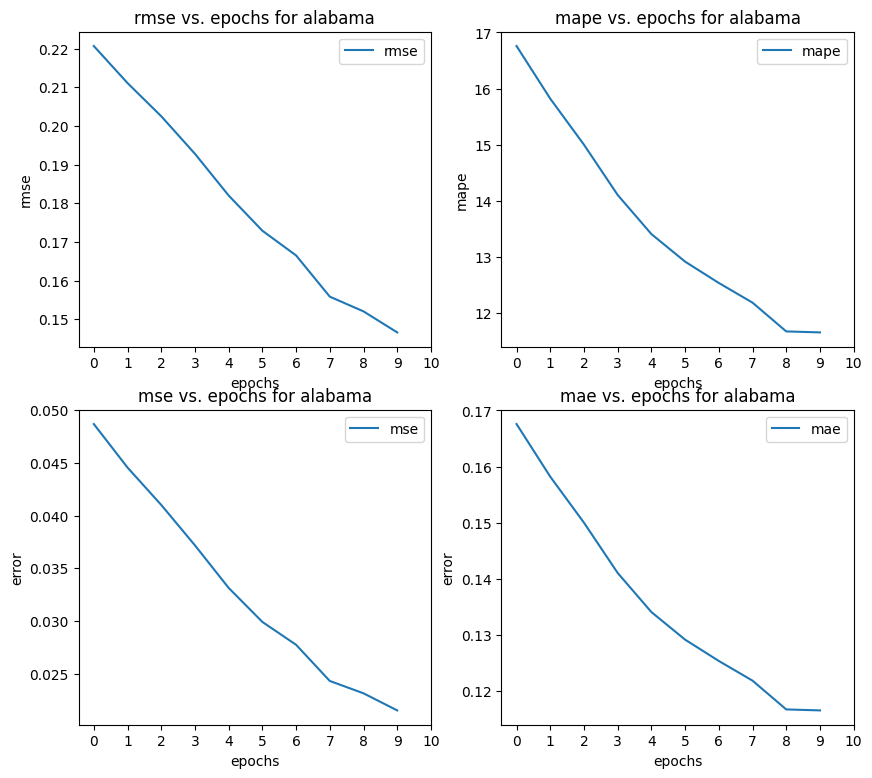

<Figure size 800x800 with 0 Axes>

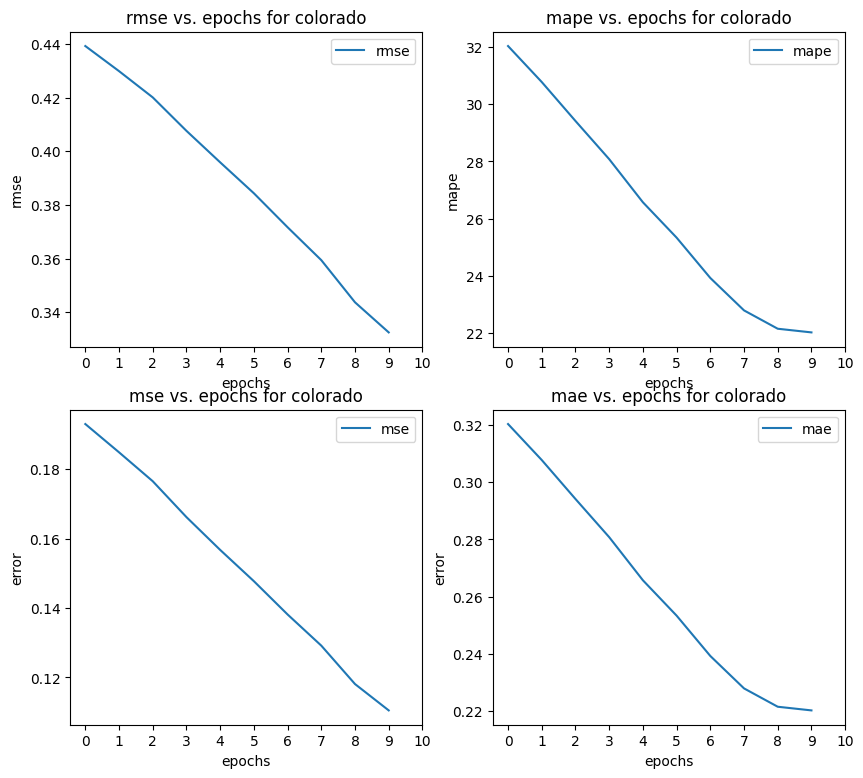

<Figure size 800x800 with 0 Axes>

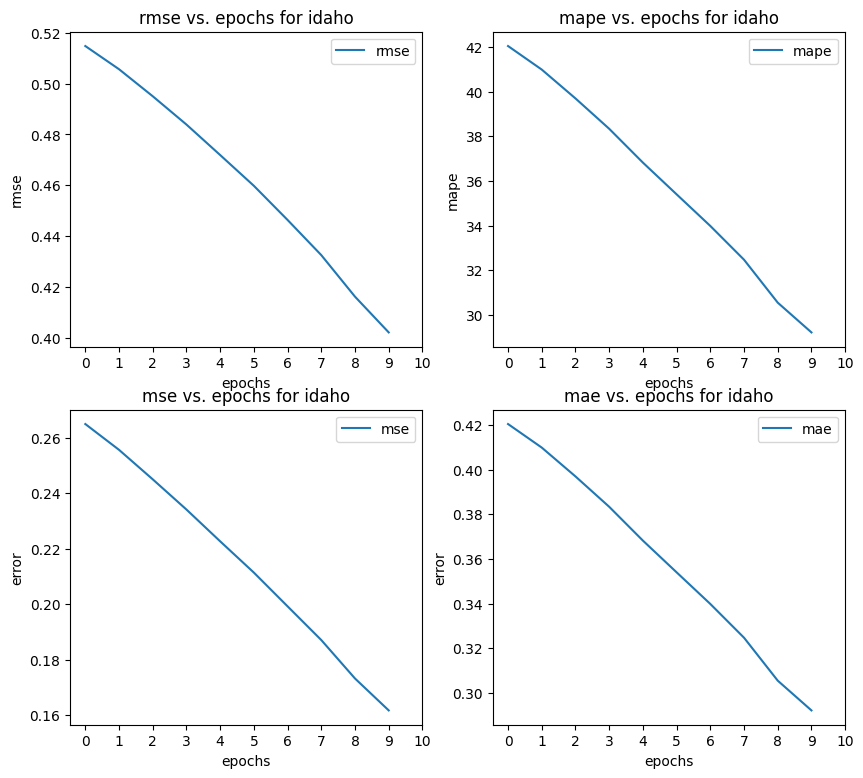

<Figure size 800x800 with 0 Axes>

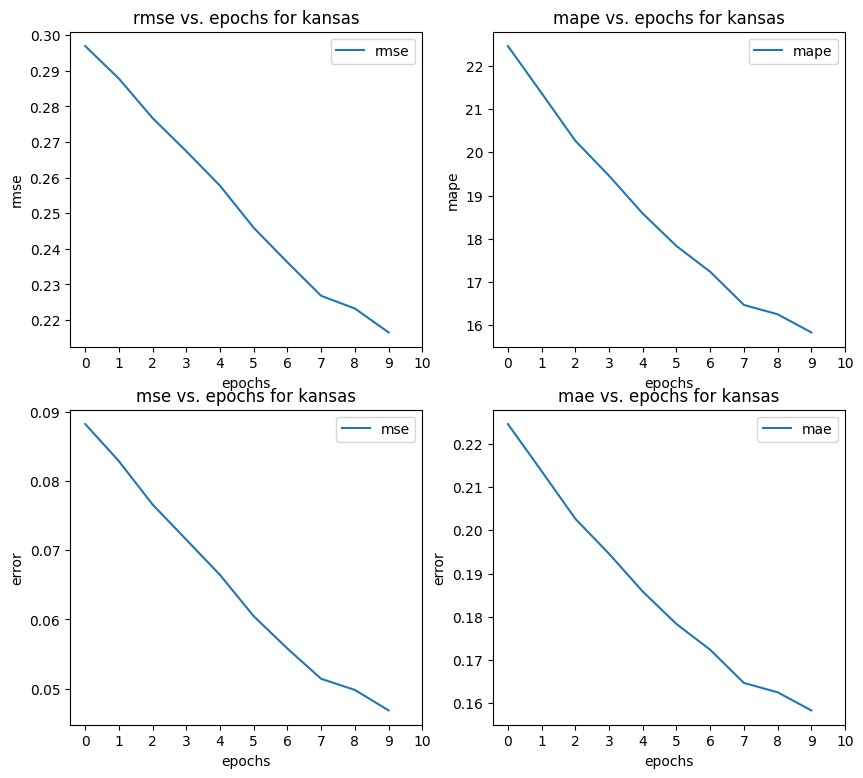

<Figure size 800x800 with 0 Axes>

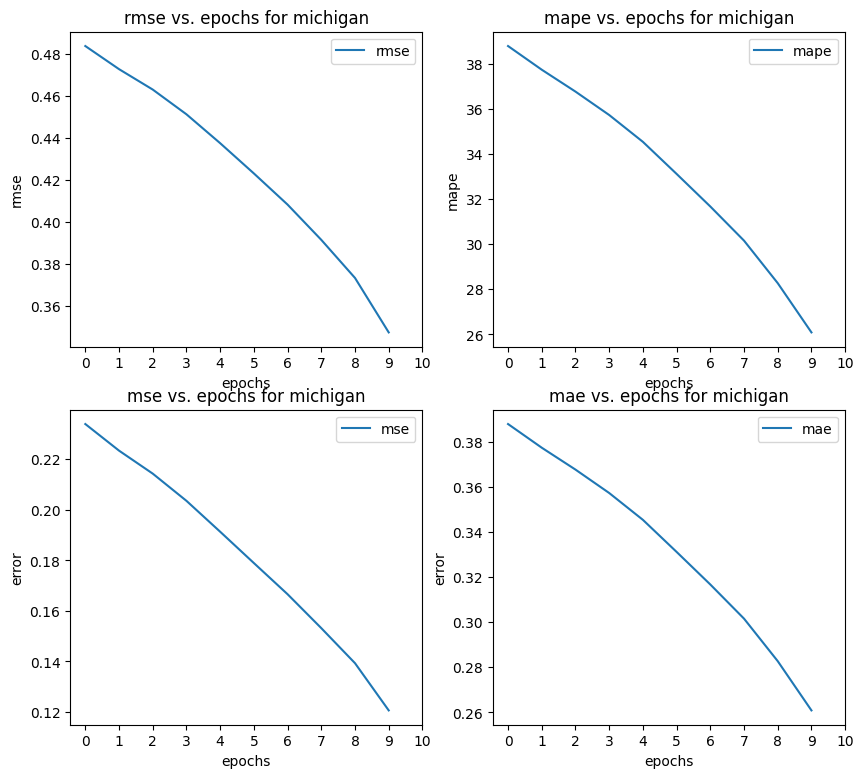

<Figure size 800x800 with 0 Axes>

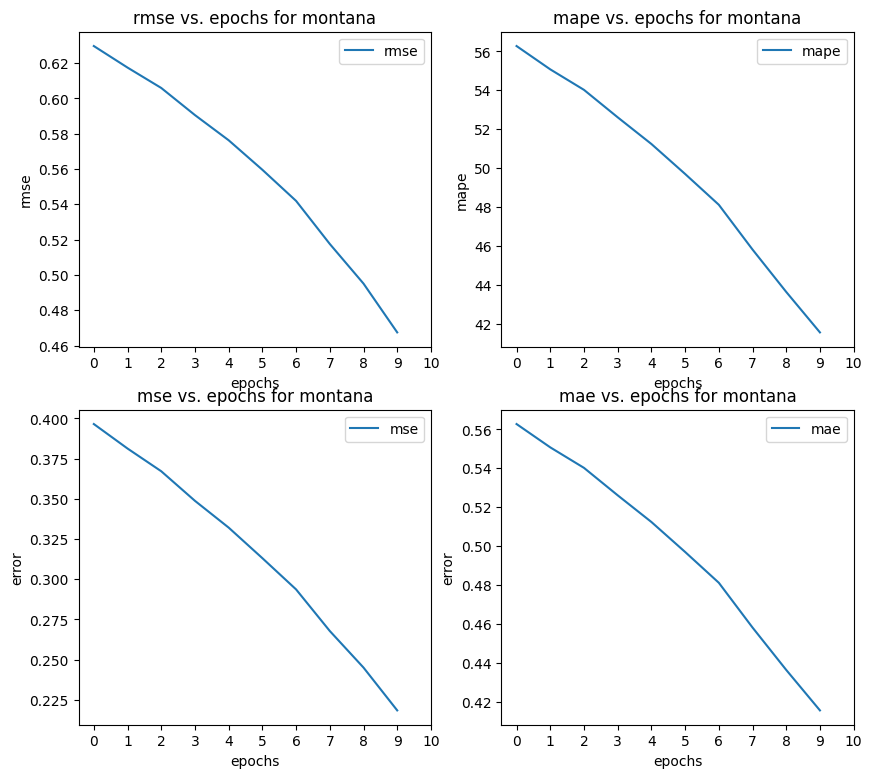

<Figure size 800x800 with 0 Axes>

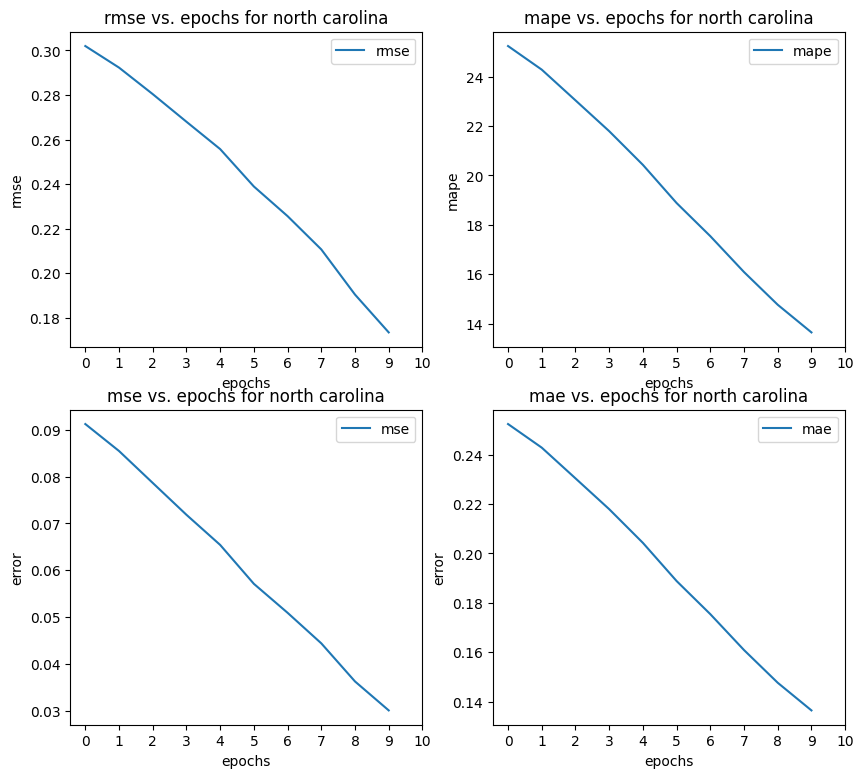

<Figure size 800x800 with 0 Axes>

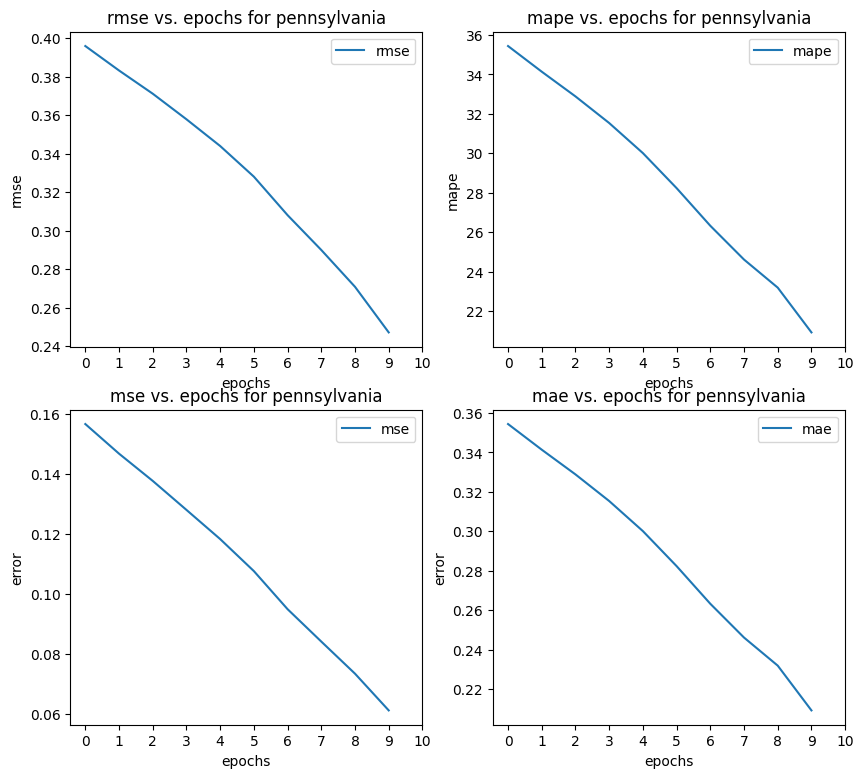

<Figure size 800x800 with 0 Axes>

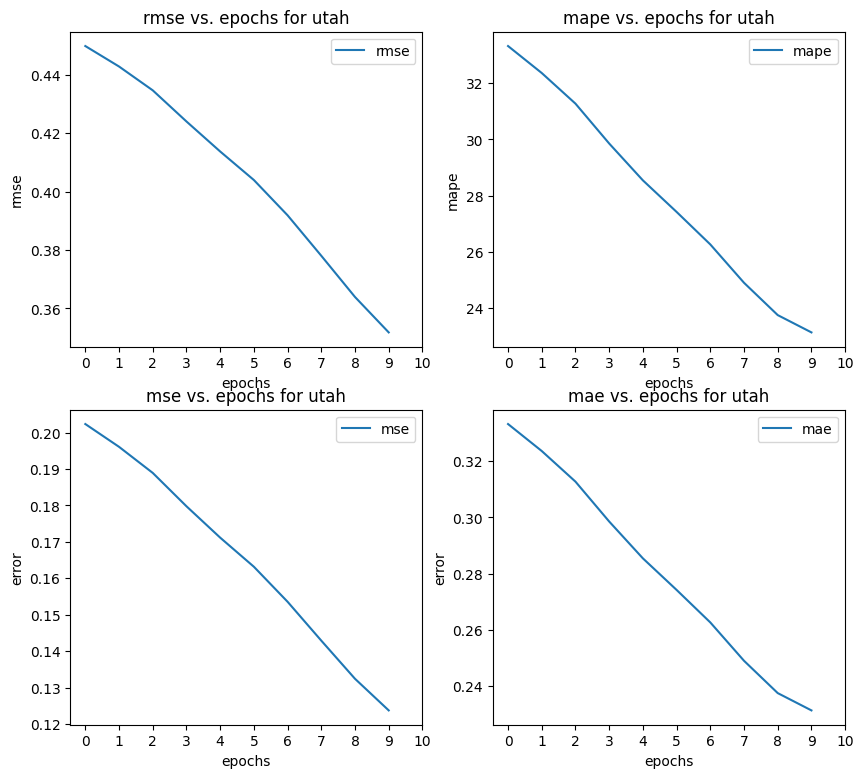

<Figure size 800x800 with 0 Axes>

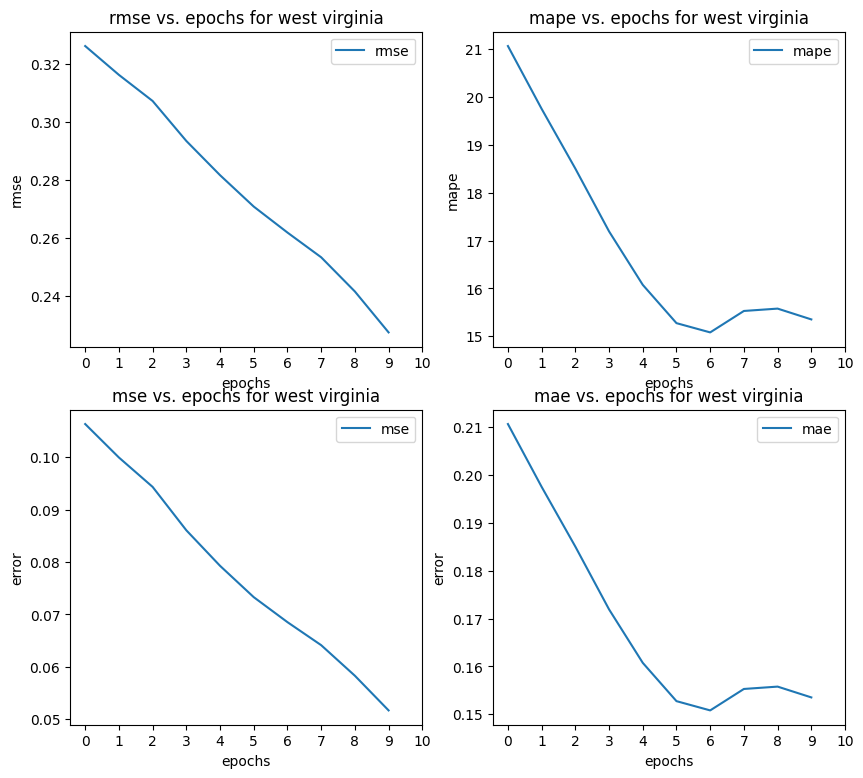

<Figure size 800x800 with 0 Axes>

In [48]:
for i, s in enumerate(states_list):
    # plot every 4 for now
    if i%4 == 0:
        fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 9))
        axs = axs.ravel()
        xPoints = np.arange(0,11)
        fig = plt.figure(figsize=(8,8))
        fig.subplots_adjust(hspace=.4, top=0.85)
        axs[0].plot(mse_error_a_dict[s]['train_lstm_rmse'], label="rmse")
        axs[0].set_title(f"rmse vs. epochs for {s}")
        axs[0].set_xlabel('epochs')
        axs[0].set_ylabel('rmse')
        axs[0].set_xticks(xPoints, labels=[i for i in xPoints])
        axs[0].legend()
        
        axs[1].plot(mse_error_a_dict[s]['train_lstm_mape'], label='mape')
        axs[1].set_title(f"mape vs. epochs for {s}")
        axs[1].set_xlabel("epochs")
        axs[1].set_ylabel("mape")
        axs[1].set_xticks(xPoints, labels=[i for i in xPoints])
        axs[1].legend()
        
        axs[2].plot(mse_error_a_dict[s]['train_lstm_mse'], label='mse')
        axs[2].set_title(f"mse vs. epochs for {s}")
        axs[2].set_xlabel("epochs")
        axs[2].set_ylabel("error")
        axs[2].set_xticks(xPoints, labels=[i for i in xPoints])
        axs[2].legend()
        
        axs[3].plot(mse_error_a_dict[s]['train_lstm_mae'], label='mae')
        axs[3].set_title(f"mae vs. epochs for {s}")
        axs[3].set_xlabel("epochs")
        axs[3].set_ylabel("error")
        axs[3].set_xticks(xPoints, labels=[i for i in xPoints])
        axs[3].legend()
        
        fig.suptitle(f"Errors vs. Epochs for {s}")
        #fig.subplots_adjust(hspace=.4, top=0.85)
        plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
        plt.show()

#### graph_df_state():

This will graph the actual and predicted bee colony numbers for each state if need examples of output. It also graphs the forecasted values.

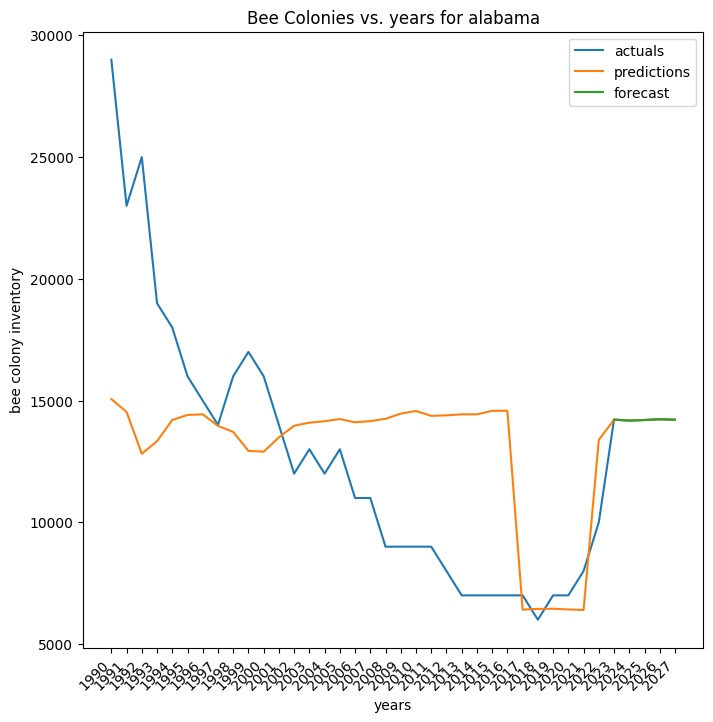

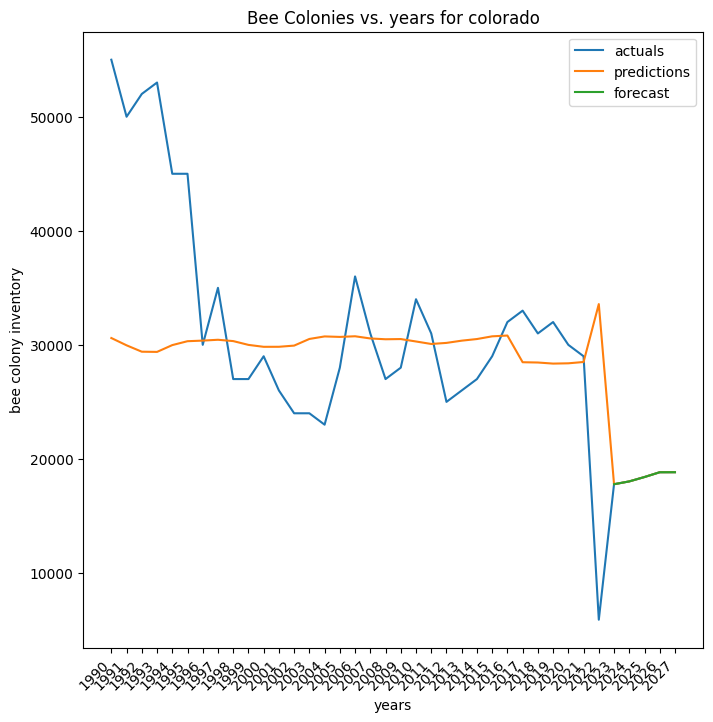

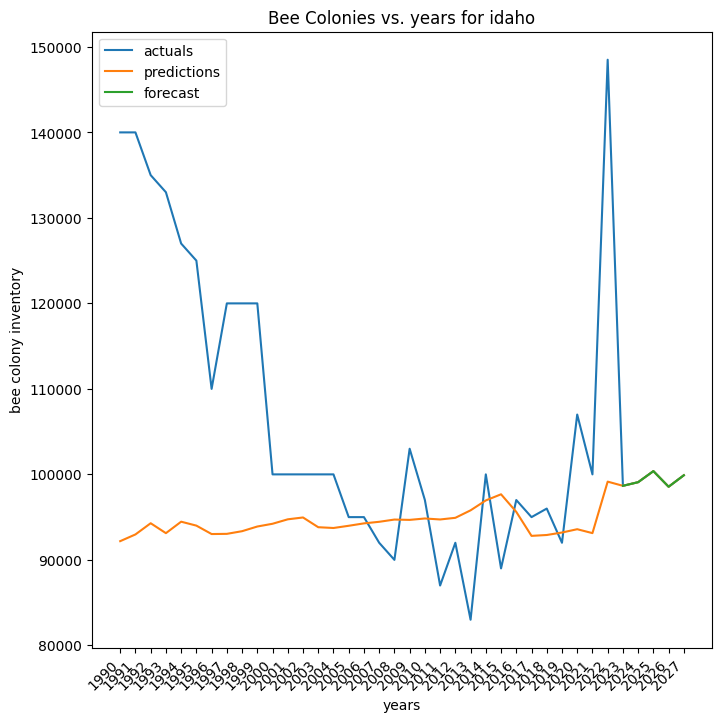

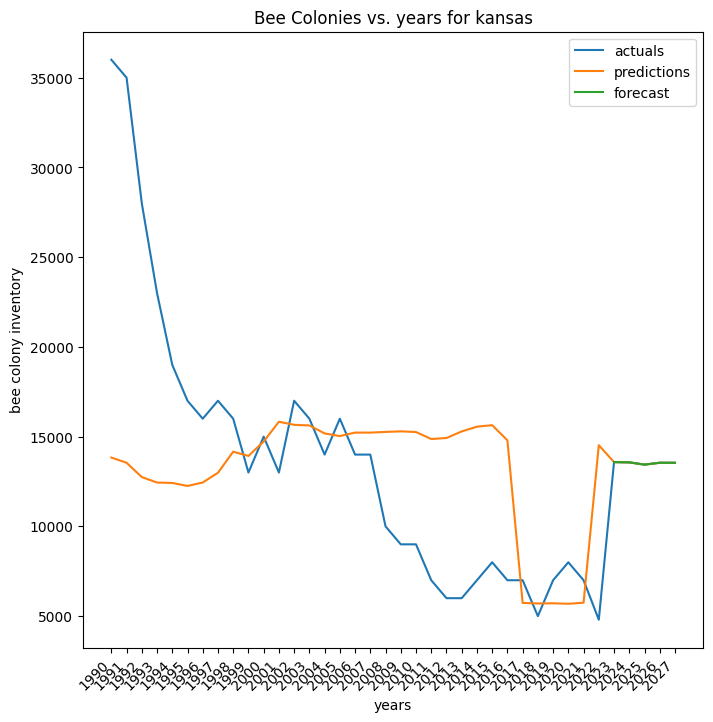

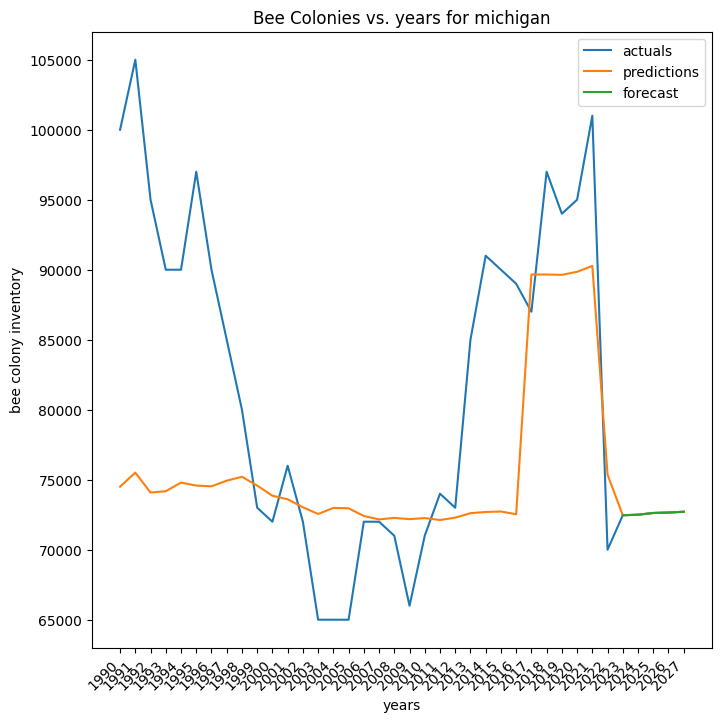

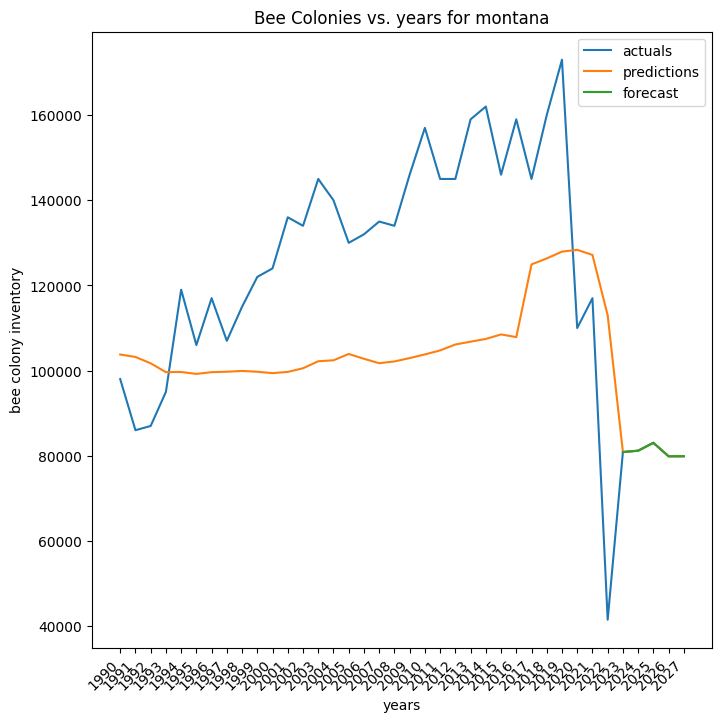

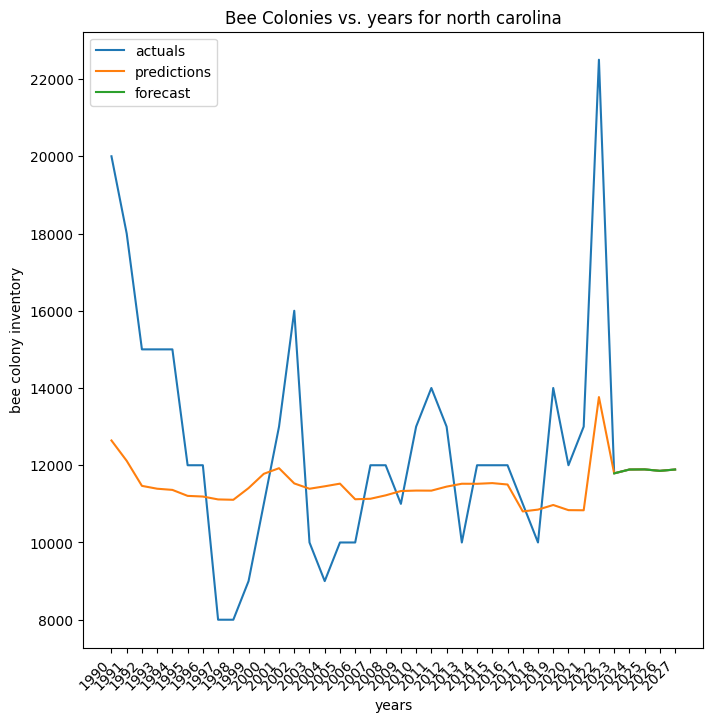

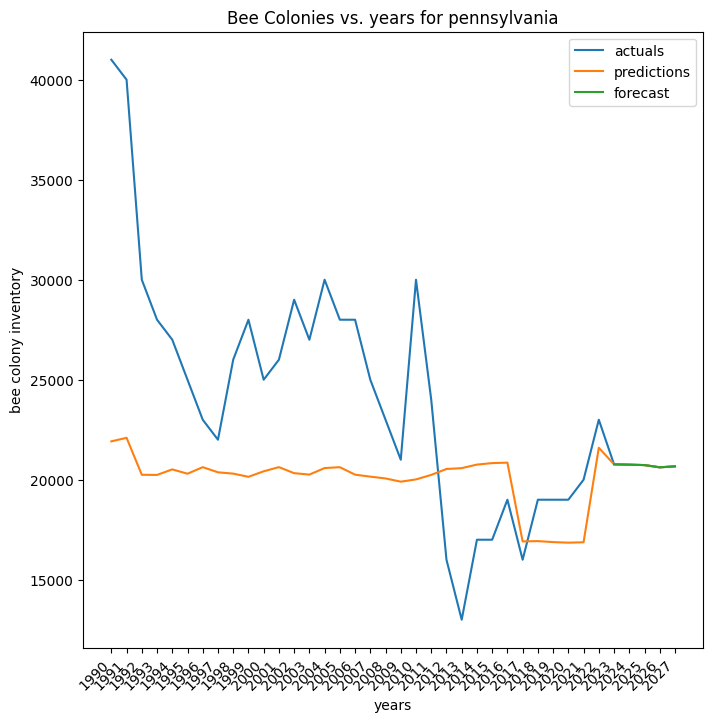

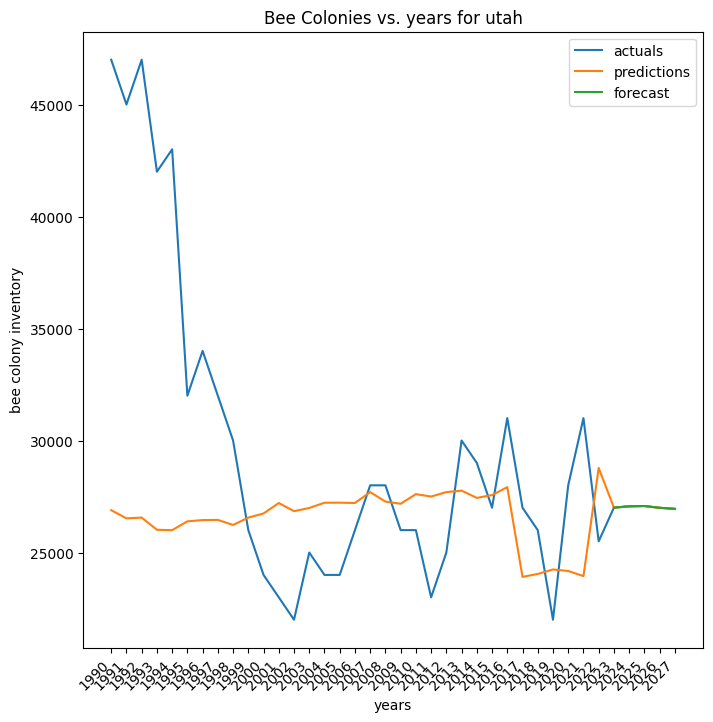

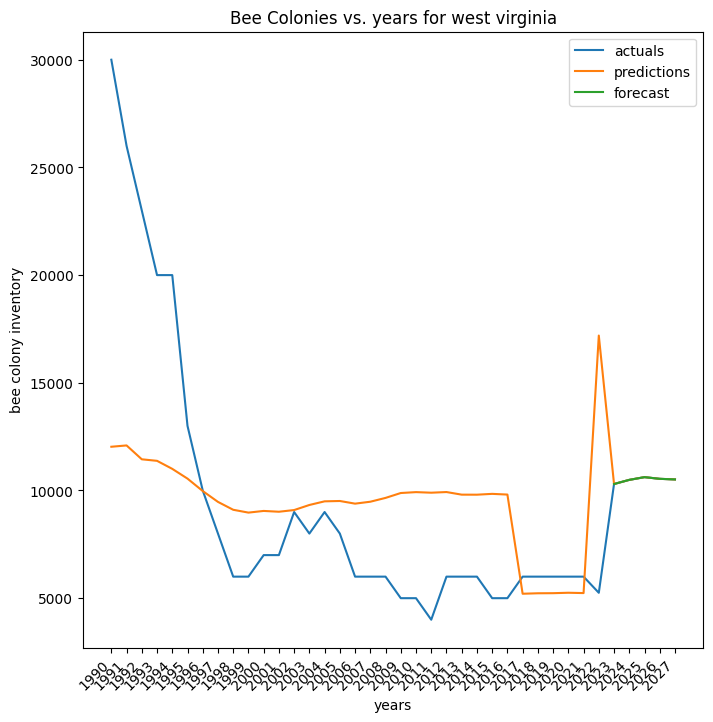

In [77]:
def graph_df_state(s, train_df, valid_df, test_df, forecast_df, i):
    final_df = pd.concat([train_df, valid_df, test_df, forecast_df],ignore_index=True)
    if (i%4) == 0:
        fig = plt.figure(figsize=(8,8))
        fig.subplots_adjust(hspace=.4)
        ax1 = fig.add_subplot(1,1,1)
        ax1.plot(final_df.loc[:, 'year'], final_df.loc[:, 'actuals'], label="actuals")
        ax1.plot(final_df.loc[:, 'year'], final_df.loc[:, 'predictions'], label="predictions")
        ax1.plot(forecast_df.loc[:, 'year'], forecast_df.loc[:, 'predictions'], label="forecast")
        ax1.set_title(f'Bee Colonies vs. years for {s}')
        plt.xlabel('years')
        plt.ylabel('bee colony inventory')
        plt.xticks(rotation = 45, ha = 'right')
        plt.legend()
        plt.show()
    return final_df

output_df = pd.DataFrame()

for i, s in enumerate(states_list):
    train_df = mse_error_a_dict[s]['train_out_df']
    test_df = mse_error_a_dict[s]['test_out_df']
    valid_df = mse_error_a_dict[s]['valid_out_df']
    forecast_df = mse_error_a_dict[s]['forecast_df']
    final_df = graph_df_state(s, train_df, valid_df, test_df, forecast_df, i)
    output_df = pd.concat([output_df, final_df], ignore_index=True)
output_df.reset_index(drop=True, inplace=True)

### ALABAMA 2017-2021 Validation graph for predictions and actuals

,predictions,actuals
year,,
2017,6413.342285,7000
2018,6444.076660,6000
2019,6451.434570,7000
2020,6420.901367,7000
2021,6401.876953,8000


Text(0.5, 1.0, 'Bee Colony Numbers vs. Years in Alabama')

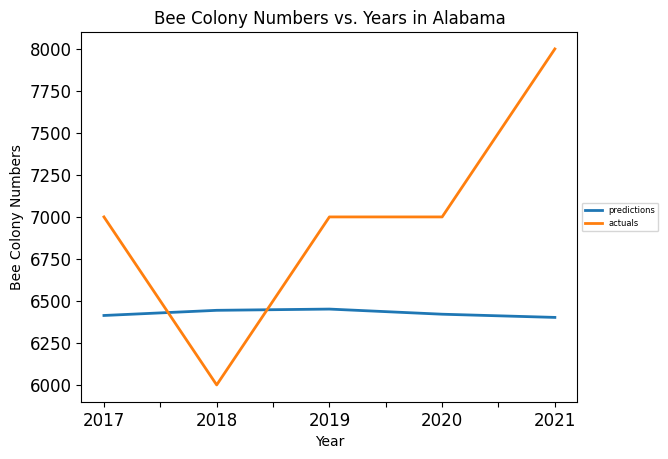

In [92]:
alabama_valid_df = mse_error_a_dict['alabama']['valid_out_df'][['year', 'predictions', 'actuals']]
alabama_valid_df.set_index(['year'], inplace=True)
display(alabama_valid_df)
axa = alabama_valid_df.plot(linewidth=2, fontsize=12)
axa.set_ylabel('Bee Colony Numbers')
axa.set_xlabel('Year')
axa.legend(loc='center left',bbox_to_anchor = (1,0.5), fontsize=6)
axa.set_title('Bee Colony Numbers vs. Years in Alabama')  

#### Aggregate the states to grap the actual and predicted using the validation data set. The results are reported in a graph and the mse_score, rmse_score and mae_score are printed.

The square root mse square error score: 5206.413892770203

mean squared error: 27106745.62283058

mae error score: 4955.182011217947

mape error score: 0.07117646726961743



,predictions,actuals
year,,
2017,64157.832031,67512.820513
2018,64113.117188,71179.487179
2019,64200.210938,70923.076923
2020,64198.441406,68128.205128
2021,64298.078125,68000.000000


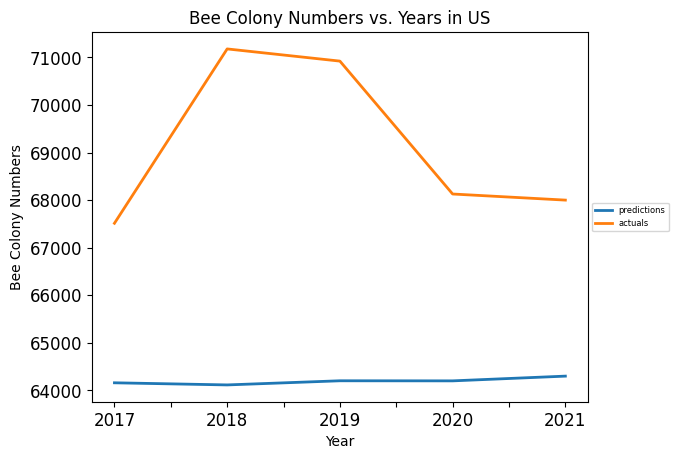

In [78]:
usa_mask = ( (pd.to_datetime(output_df['year']).dt.year >= 2017) & (pd.to_datetime(output_df['year']).dt.year <= 2021))
usa_valid = output_df[usa_mask].copy()
usa_df=usa_valid.groupby('year')[['predictions', 'actuals']].mean()


ax = usa_df.plot(linewidth=2, fontsize=12)
ax.set_ylabel('Bee Colony Numbers')
ax.set_xlabel('Year')
ax.legend(loc='center left',bbox_to_anchor = (1,0.5), fontsize=6)
ax.set_title('Bee Colony Numbers vs. Years in US')  

rmse_score = sqrt(mean_squared_error(usa_df.loc[:,'actuals'], usa_df.loc[:,'predictions']))
mse_score = mean_squared_error(usa_df.loc[:,'actuals'], usa_df.loc[:,'predictions'])
mae_score = mean_absolute_error(usa_df.loc[:,'actuals'], usa_df.loc[:,'predictions'])
mape_score = mean_absolute_percentage_error(usa_df.loc[:,'actuals'], usa_df.loc[:,'predictions'])
print(f"The square root mse square error score: {rmse_score}\n")
print(f"mean squared error: {mse_score}\n")
print(f"mae error score: {mae_score}\n")
print(f"mape error score: {mape_score}\n")
display(usa_df)

#### Obtain the 2017-2021 errors matrices for each of the states

In [79]:
year_list = [2017, 2018, 2019, 2020, 2021]

for i, y in enumerate(year_list):
    for j, s in enumerate(states_list):
        state_valid_df = mse_error_a_dict[s]['valid_out_df']
        state_valid_mask = (pd.to_datetime(state_valid_df['year']).dt.year == y)
        state_valid_df = state_valid_df[state_valid_mask].copy()
        state_valid_df.reset_index(drop=True, inplace=True)
        rmse_test_score = sqrt(mean_squared_error(state_valid_df.loc[:,'actuals'], state_valid_df.loc[:,'predictions']))
        mse_test_score = mean_squared_error(state_valid_df.loc[:,'actuals'], state_valid_df.loc[:,'predictions'])
        mae_test_score = mean_absolute_error(state_valid_df.loc[:,'actuals'], state_valid_df.loc[:,'predictions'])
        mape_test_score = mean_absolute_percentage_error(state_valid_df.loc[:,'actuals'], state_valid_df.loc[:,'predictions'])
        print(f"******Error results for the validation set: {s} year: {y} ******")
        print(f"The square root mse square error for test: {rmse_test_score}\n")
        print(f"mean squared error for test: {mse_test_score}\n")
        print(f"mae error for test: {mae_test_score}\n")
        print(f"mape error for test: {mape_test_score}\n")

******Error results for the validation set: alabama year: 2017 ******
The square root mse square error for test: 586.65771484375

mean squared error for test: 344167.2743856907

mae error for test: 586.65771484375

mape error for test: 0.08380824497767857

******Error results for the validation set: arizona year: 2017 ******
The square root mse square error for test: 1270.189453125

mean squared error for test: 1613381.2468299866

mae error for test: 1270.189453125

mape error for test: 0.057735884232954546

******Error results for the validation set: arkansas year: 2017 ******
The square root mse square error for test: 9319.05859375

mean squared error for test: 86844853.07374573

mae error for test: 9319.05859375

mape error for test: 0.3213468480603448

******Error results for the validation set: california year: 2017 ******
The square root mse square error for test: 47978.40625

mean squared error for test: 2301927466.290039

mae error for test: 47978.40625

mape error for test: 0.

******Error results for the validation set: north dakota year: 2019 ******
The square root mse square error for test: 46845.78125

mean squared error for test: 2194527220.9228516

mae error for test: 46845.78125

mape error for test: 0.09008804086538462

******Error results for the validation set: ohio year: 2019 ******
The square root mse square error for test: 105.5263671875

mean squared error for test: 11135.814171791077

mae error for test: 105.5263671875

mape error for test: 0.0070350911458333335

******Error results for the validation set: oregon year: 2019 ******
The square root mse square error for test: 10640.3828125

mean squared error for test: 113217746.39654541

mae error for test: 10640.3828125

mape error for test: 0.12230325071839081

******Error results for the validation set: pennsylvania year: 2019 ******
The square root mse square error for test: 2119.068359375

mean squared error for test: 4490450.711704254

mae error for test: 2119.068359375

mape error for test

In [85]:
print(f"**** STATE LEVEL ERRORS ****\n")
for i, y in enumerate(year_list):
    year_valid_mask = (pd.to_datetime(output_df['year']).dt.year == y)
    year_valid_df = output_df[year_valid_mask].copy()
    year_valid_df.reset_index(drop=True, inplace=True)
    rmse_test_score = sqrt(mean_squared_error(year_valid_df.loc[:,'actuals'], year_valid_df.loc[:,'predictions']))
    mse_test_score = mean_squared_error(year_valid_df.loc[:,'actuals'], year_valid_df.loc[:,'predictions'])
    mae_test_score = mean_absolute_error(year_valid_df.loc[:,'actuals'], year_valid_df.loc[:,'predictions'])
    mape_test_score = mean_absolute_percentage_error(year_valid_df.loc[:,'actuals'], year_valid_df.loc[:,'predictions'])
    print(f"******Error state level results for the validation set year: {y} ******")
    print(f"The square root mse square error for test: {rmse_test_score}\n")
    print(f"mean squared error for test: {mse_test_score}\n")
    print(f"mae error for test: {mae_test_score}\n")
    print(f"mape error for test: {mape_test_score}\n")

print(f"\n\n**** US LEVEL ERRORS ****\n\n")
usa_mask = ( (pd.to_datetime(output_df['year']).dt.year >= 2017) & (pd.to_datetime(output_df['year']).dt.year <= 2021))
usa_valid = output_df[usa_mask].copy()
usa_df=usa_valid.groupby('year')[['predictions', 'actuals']].mean()
usa_df.reset_index(inplace=True)

for i, y in enumerate(year_list):
    year_usa_mask = (pd.to_datetime(usa_df['year']).dt.year == y)
    year_usa_df = usa_df[year_usa_mask].copy()
    year_usa_df.reset_index(drop=True, inplace=True)
    rmse_test_score = sqrt(mean_squared_error(year_usa_df.loc[:,'actuals'], year_usa_df.loc[:,'predictions']))
    rmse_test_score = sqrt(mean_squared_error(year_usa_df.loc[:,'actuals'], year_usa_df.loc[:,'predictions']))
    mse_test_score = mean_squared_error(year_usa_df.loc[:,'actuals'], year_usa_df.loc[:,'predictions'])
    mae_test_score = mean_absolute_error(year_usa_df.loc[:,'actuals'], year_usa_df.loc[:,'predictions'])
    mape_test_score = mean_absolute_percentage_error(year_usa_df.loc[:,'actuals'], year_usa_df.loc[:,'predictions'])
    print(f"******Error US level results for the validation set year: {y} ******")
    print(f"The square root mse square error for test: {rmse_test_score}\n")
    print(f"mean squared error for test: {mse_test_score}\n")
    print(f"mae error for test: {mae_test_score}\n")
    print(f"mape error for test: {mape_test_score}\n")

**** STATE LEVEL ERRORS ****

******Error state level results for the validation set year: 2017 ******
The square root mse square error for test: 10321.88317681879

mean squared error for test: 106541272.31589477

mae error for test: 5093.300318008814

mape error for test: 0.10773052218274146

******Error state level results for the validation set year: 2018 ******
The square root mse square error for test: 16478.358214412543

mean squared error for test: 271536289.4424974

mae error for test: 7318.576685196314

mape error for test: 0.1030915532633198

******Error state level results for the validation set year: 2019 ******
The square root mse square error for test: 14296.662466221404

mean squared error for test: 204394557.67306387

mae error for test: 6911.167918669872

mape error for test: 0.12316698127461155

******Error state level results for the validation set year: 2020 ******
The square root mse square error for test: 11226.505588158772

mean squared error for test: 126034427.

#### Obtain the 2022 predicted bee colony value and display for the US

In [70]:
# get 2022
usa_mask = (pd.to_datetime(output_df['year']).dt.year == 2022)
usa_test_df = output_df[usa_mask].copy()
usa_test_df.reset_index(drop=True, inplace=True)

rmse_test_score = sqrt(mean_squared_error(usa_test_df.loc[:,'actuals'], usa_test_df.loc[:,'predictions']))
mse_test_score = mean_squared_error(usa_test_df.loc[:,'actuals'], usa_test_df.loc[:,'predictions'])
mae_test_score = mean_absolute_error(usa_test_df.loc[:,'actuals'], usa_test_df.loc[:,'predictions'])
mape_test_score = mean_absolute_percentage_error(usa_test_df.loc[:,'actuals'], usa_test_df.loc[:,'predictions'])
print(f"******Error results for the test set taking each states predictions and actuals******")
print(f"The square root mse square error for test: {rmse_test_score}\n")
print(f"mean squared error for test: {mse_test_score}\n")
print(f"mae error for test: {mae_test_score}\n")
print(f"mape error for test: {mape_test_score}\n")
display(usa_test_df)
print("-----------------------------------")
print("\n\n\n")
usa_test_agg_df=usa_test_df.groupby('year')[['predictions', 'actuals']].mean().reset_index()
display(usa_test_agg_df.head())
rmse_test_score = sqrt(mean_squared_error(usa_test_agg_df.loc[:,'actuals'], usa_test_agg_df.loc[:,'predictions']))
mse_test_score = mean_squared_error(usa_test_agg_df.loc[:,'actuals'], usa_test_agg_df.loc[:,'predictions'])
mae_test_score = mean_absolute_error(usa_test_agg_df.loc[:,'actuals'], usa_test_agg_df.loc[:,'predictions'])
mape_test_score = mean_absolute_percentage_error(usa_test_agg_df.loc[:,'actuals'], usa_test_agg_df.loc[:,'predictions'])
print(f"******Error results from aggregate of US test set******")
print(f"The square root mse square error for test: {rmse_test_score}\n")
print(f"mean squared error for test: {mse_test_score}\n")
print(f"mae error for test: {mae_test_score}\n")
print(f"mape error for test: {mape_test_score}\n")
print("-----------------------------------")


******Error results for the test set taking each states predictions and actuals******
The square root mse square error for test: 126765.80552724274

mean squared error for test: 16069569450.970728

mae error for test: 53827.166691706734

mape error for test: 1.268028202198619



,year,state,predictions,actuals
0,2022,alabama,13386.191406,10000.0
1,2022,arizona,54252.472656,28000.0
2,2022,arkansas,33060.656250,18750.0
3,2022,california,386954.093750,1000000.0
4,2022,colorado,33576.570312,5900.0
5,2022,florida,180492.218750,292500.0
6,2022,georgia,79481.617188,125000.0
7,2022,hawaii,7316.504395,21500.0
8,2022,idaho,99151.046875,148500.0
9,2022,illinois,15918.224609,10250.0


-----------------------------------






,year,predictions,actuals
0,2022,67394.203125,72673.076923


******Error results from aggregate of US test set******
The square root mse square error for test: 5278.873798076922

mean squared error for test: 27866508.57602307

mae error for test: 5278.873798076922

mape error for test: 0.07263864448266735

-----------------------------------


#### Display the validation dataframe

In [71]:
usa_mask = ( (pd.to_datetime(output_df['year']).dt.year >= 2017) & (pd.to_datetime(output_df['year']).dt.year <= 2021))
usa_valid = output_df[usa_mask].copy()
usa_df=usa_valid.groupby('year')[['predictions', 'actuals']].mean()

display(usa_df)

,predictions,actuals
year,,
2017,64157.832031,67512.820513
2018,64113.117188,71179.487179
2019,64200.210938,70923.076923
2020,64198.441406,68128.205128
2021,64298.078125,68000.000000


#### Display the forecast dataframe

In [72]:
usa_forecast_mask = (pd.to_datetime(output_df['year']).dt.year > 2022)
usa_forecast = output_df[usa_forecast_mask].copy()
usa_forecast_df=usa_forecast.groupby('year')[['predictions', 'actuals']].mean()

display(usa_forecast_df)

,predictions,actuals
year,,
2023,52916.437500,52916.438276
2024,53025.062500,53025.063514
2025,53310.003906,53310.003718
2026,53293.843750,53293.844601
2027,53466.878906,53466.876665


**Output graph for the validation using the one hot encoding**

The quare root mse square error score: 35082.86202089476
mean squared error: 1230807207.57714
mae error score: 34949.45622996795



,predictions,actuals
year,,
2017-01-01,36708.851562,67512.820513
2018-01-01,35945.445312,71179.487179
2019-01-01,35936.089844,70923.076923
2020-01-01,27940.125000,68128.205128
2021-01-01,34465.796875,68000.000000


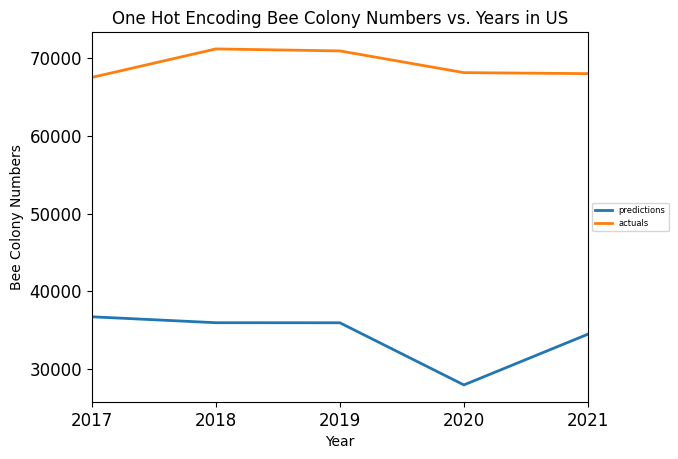

In [73]:
usa_one_df=h_valid_df.groupby('year')[['predictions', 'actuals']].mean()
ax = usa_one_df.plot(linewidth=2, fontsize=12)
ax.set_ylabel('Bee Colony Numbers')
ax.set_xlabel('Year')
ax.legend(loc='center left',bbox_to_anchor = (1,0.5), fontsize=6)
ax.set_title('One Hot Encoding Bee Colony Numbers vs. Years in US')  

rmse_one_score = sqrt(mean_squared_error(usa_one_df.loc[:,'actuals'], usa_one_df.loc[:,'predictions']))
mse_one_score = mean_squared_error(usa_one_df.loc[:,'actuals'], usa_one_df.loc[:,'predictions'])
mae_one_score = mean_absolute_error(usa_one_df.loc[:,'actuals'], usa_one_df.loc[:,'predictions'])
mape_one_score = mean_absolute_percentage_error(usa_one_df.loc[:,'actuals'], usa_one_df.loc[:,'predictions'])
print(f"The quare root mse square error score: {rmse_one_score}\nmean squared error: {mse_one_score}\nmae error score: {mae_one_score}\n")
display(usa_one_df)

### The following is code for development when worked on forecast to work with one state. Not code for analysis. After this no output for report.

In [74]:
test_df = mse_error_a_dict['alabama']['test_out_df']
valid_df = mse_error_a_dict['alabama']['valid_out_df']
print(test_df)
print(valid_df)

   year    state   predictions  actuals
0  2022  alabama  13386.191406    10000
   year    state  predictions  actuals
0  2017  alabama  6413.342285     7000
1  2018  alabama  6444.076660     6000
2  2019  alabama  6451.434570     7000
3  2020  alabama  6420.901367     7000
4  2021  alabama  6401.876953     8000


In [ ]:
# forecast HERE This is just taking one example to get the function working for forecast

forecast_years = 5
train_a_dates = state_data_a_dict['train']['dates']
valid_a_dates = state_data_a_dict['valid']['dates']
test_a_dates = state_data_a_dict['test']['dates']

dt_year = pd.to_datetime(test_a_dates[-1:][0])
forcast_period_years = pd.date_range(dt_year, periods=forecast_years, freq='AS').tolist()

s = 'alabama'
v = state_data_a_dict['train'][s]

file_best_dir = "saved_models/" + s
file_best_dir_path = abspath(file_best_dir)
file_best_name = file_best_dir + "/weights-improvement-state-a.hdf5"
file_best_path = abspath(file_best_name)
    
model = load_model(file_best_path)
        
x_matrix_train_data = state_data_a_dict['train'][s]['x_matrix']
y_matrix_train_data = state_data_a_dict['train'][s]['y_matrix']
x_scaled_train_data = state_data_a_dict['train'][s]['x_scaled']
y_scaled_train_data = state_data_a_dict['train'][s]['y_scaled']
y_orig_train_data = state_data_a_dict['train'][s]['y_matrix']
y_train_scaler = state_data_a_dict['train'][s]['y_scaler']
x_train_scaler = state_data_a_dict['train'][s]['x_scaler']
    
x_matrix_valid_data = state_data_a_dict['valid'][s]['x_matrix']
y_matrix_valid_data = state_data_a_dict['valid'][s]['y_matrix']
x_scaled_valid_data = state_data_a_dict['valid'][s]['x_scaled']
y_scaled_valid_data = state_data_a_dict['valid'][s]['y_scaled']
y_orig_valid_data = state_data_a_dict['valid'][s]['y_matrix']
y_valid_scaler = state_data_a_dict['valid'][s]['y_scaler']
x_valid_scaler = state_data_a_dict['valid'][s]['x_scaler']
  
x_matrix_test_data = state_data_a_dict['test'][s]['x_matrix']
y_matrix_test_data = state_data_a_dict['test'][s]['y_matrix']
x_scaled_test_data = state_data_a_dict['test'][s]['x_scaled']
y_scaled_test_data = state_data_a_dict['test'][s]['y_scaled']
y_orig_test_data = state_data_a_dict['test'][s]['y_matrix'][:,np.newaxis]
y_test_scaler = state_data_a_dict['test'][s]['y_scaler']
x_test_scaler = state_data_a_dict['test'][s]['x_scaler']
    
last_output = []
n_steps = 1
i=0
    
print(f"x_scaled_test_data = {x_scaled_test_data} x_matrix_test_data {x_matrix_train_data} type = {type(x_matrix_train_data)}")
# HERE LEFT OFF
forecast_df = forecast_future_years(model, forecast_years, s, x_matrix_train_data, y_matrix_train_data,
                                    x_matrix_valid_data, y_matrix_valid_data,
                                    x_matrix_test_data, y_matrix_test_data, 
                                    train_a_dates, valid_a_dates, test_a_dates)


In [ ]:
display(forecast_df)

### References

1. https://www.youtube.com/watch?v=kGdbPnMCdOg&t=500s

2. https://www.youtube.com/watch?v=S8tpSG6Q2H0

3. https://www.geeksforgeeks.org/understanding-of-lstm-networks/#:~:text=LSTMs%20provide%20us%20with%20a,)%2C%20which%20is%20an%20advantage.

4. https://stackoverflow.com/questions/49729522/why-is-the-mean-average-percentage-errormape-extremely-high

5. https://machinelearningmastery.com/adam-optimization-algorithm-for-deep-learning/

6. https://machinelearningmastery.com/rectified-linear-activation-function-for-deep-learning-neural-networks/#:~:text=The%20rectified%20linear%20activation%20function,otherwise%2C%20it%20will%20output%20zero.